# 03 — Multi-Agent Q-Learning for Shared Grid Navigation


## What this notebook covers

- single-agent vs. multi-agent Q-learning;
- formal Markov-game notation;
- global state and each agent's observation;
- joint action space;
- reward design from each agent's perspective;
- simultaneous actions and collision rules;
- independent Q-learning equations for Agent 1 and Agent 2;
- manual Q-value calculations;
- first 60 Q-updates for each agent;
- individual Q-tables and Q-table snapshots;
- reward, success, collision, and convergence graphs;
- greedy policies and learned paths;
- animated two-agent simulation;
- state-space growth and why deep MARL becomes useful.

# 1. From Single-Agent to Multi-Agent Q-Learning

For one Q-learning agent,

$$
S_t \xrightarrow{A_t} R_{t+1},S_{t+1},
$$

and the agent learns

$$
Q(s,a).
$$

With two agents acting in the same environment,

$$
S_t
\xrightarrow{(A_t^1,A_t^2)}
(R_{t+1}^1,R_{t+1}^2,S_{t+1}).
$$

Each agent can maintain its own action-value function:

$$
Q_1(o_1,a_1)
$$

and

$$
Q_2(o_2,a_2),
$$

where $o_i$ is the observation used by Agent $i$.

The important difference is that **Agent 1's next state can depend on Agent 2's action**, and vice versa.

# 2. What Is Multi-Agent Reinforcement Learning?

**Multi-Agent Reinforcement Learning (MARL)** studies reinforcement-learning problems in which **more than one agent learns and acts in the same environment**.

In single-agent reinforcement learning, one agent interacts with the environment:

$$
S_t
\xrightarrow{A_t}
R_{t+1},S_{t+1}.
$$

The environment changes because of the action of that one agent.

In multi-agent reinforcement learning, several agents act at the same time:

$$
S_t
\xrightarrow{(A_t^1,A_t^2,\ldots,A_t^N)}
(R_{t+1}^1,R_{t+1}^2,\ldots,R_{t+1}^N,S_{t+1}).
$$

Therefore, the next state depends on the **joint actions** of all agents.

For two agents,

$$
S_{t+1}
\sim
P
\left(
S_{t+1}
\mid
S_t,A_t^1,A_t^2
\right).
$$

Each agent may receive its own reward:

$$
R_{t+1}^1
\qquad\text{and}\qquad
R_{t+1}^2.
$$

Each agent may also learn its own policy:

$$
\pi_1(a_1|o_1)
$$

and

$$
\pi_2(a_2|o_2).
$$

In this notebook, each robot is treated as one learning agent.

## 2.1 Single-Agent Q-Learning vs. Multi-Agent Q-Learning

### Single-agent Q-learning

There is one learner:

$$
Q(s,a).
$$

The agent selects an action, receives a reward, observes the next state, and updates

$$
Q(s,a).
$$

The transition depends only on the current state and the single agent's action:

$$
P(s'|s,a).
$$

### Multi-agent Q-learning

There are multiple learners.

For two independent Q-learning agents:

$$
Q_1(o_1,a_1)
$$

and

$$
Q_2(o_2,a_2).
$$

Now the transition depends on both actions:

$$
P(s'|s,a_1,a_2).
$$

This means that Agent 1 cannot completely control what happens after selecting $a_1$, because Agent 2 is also acting.

A compact comparison is:

| Single-Agent RL | Multi-Agent RL |
|---|---|
| One learning agent | Two or more learning agents |
| One action affects transition | Joint actions affect transition |
| Environment can be stationary | Other learners can make it non-stationary |
| One policy | Multiple policies |
| One reward signal is common | Each agent may receive a different reward |
| Smaller state/action spaces | Joint spaces can grow rapidly |

# 3. Why Is Multi-Agent Reinforcement Learning Harder?

Multi-agent reinforcement learning is harder because **each agent is learning inside an environment that contains other learning agents**.

That creates several additional difficulties.

### 1. Non-stationarity

In ordinary Q-learning, the agent assumes that the environment dynamics do not keep changing while it learns.

For one agent,

$$
P(S_{t+1}|S_t,A_t)
$$

is treated as stable.

In a multi-agent environment,

$$
P(S_{t+1}|S_t,A_t^1,A_t^2)
$$

depends on the other agent's behavior.

If Agent 2 changes its policy during training, the environment experienced by Agent 1 also changes.

So from Agent 1's perspective,

$$
P_t(S_{t+1}|S_t,A_t^1)
$$

may be different at different stages of training.

This is called **non-stationarity**.

## 3.1 Coordination Problem

Two agents may individually choose actions that look good but are bad when combined.

For example:

- Agent 1 chooses `Right`.
- Agent 2 chooses `Left`.
- Both attempt to enter the same cell.

Individually, each action may appear reasonable.

Together, the joint action

$$
(A_t^1,A_t^2)
$$

causes a collision.

Therefore, each agent must learn behavior that works **with the behavior of the other agent**, not only behavior that is good in isolation.

## 3.2 State-Space Growth

Suppose one robot moves in an $8\times8$ grid.

One robot has

$$
64
$$

possible position states.

If two robot positions must be represented together,

$$
64^2
=
4096
$$

joint-position states are possible.

For three agents,

$$
64^3
=
262{,}144.
$$

For $N$ agents with $M$ possible positions each,

$$
|\mathcal S_{\text{joint}}|
=
M^N.
$$

The state space therefore grows exponentially with the number of agents.

## 3.3 Joint Action-Space Growth

If every agent has $m$ actions, then one agent has

$$
m
$$

actions.

Two agents have

$$
m^2
$$

joint-action combinations.

For this notebook, each agent has five actions, so

$$
5^2
=
25
$$

joint actions are possible at each step.

For $N$ agents,

$$
|\mathcal A_{\text{joint}}|
=
m^N.
$$

This rapid growth makes centralized tabular methods increasingly difficult as the number of agents increases.

## 3.4 Credit Assignment

Suppose the team receives a good outcome.

Which agent caused it?

If both agents receive one shared team reward,

$$
R_{\text{team}},
$$

it may be difficult to determine whether Agent 1, Agent 2, or their combined behavior was responsible.

This is called the **credit-assignment problem**.

In this notebook, each agent receives an individual reward so that the learning signal is easier to interpret:

$$
r_1
\qquad\text{and}\qquad
r_2.
$$

## 3.5 Partial Observability

In a real multi-robot system, one robot may not know the complete global state.

It may only observe nearby information:

$$
o_i
=
(
\text{own position},
\text{nearby obstacles},
\text{nearby agents}
).
$$

Therefore,

$$
o_i \neq S
$$

in general.

An agent must make decisions using incomplete information about the full environment.

Our grid example is simpler because both agents observe both positions.

## 3.6 Exploration Can Interfere with Other Agents

In single-agent learning, exploration mainly affects the exploring agent.

In multi-agent learning, one agent's exploratory action can affect everyone.

For example, Agent 1 may randomly explore:

$$
A_t^1=\text{Right},
$$

while Agent 2 expected Agent 1 to remain on another route.

That exploratory move can:

- block Agent 2;
- cause a collision;
- change Agent 2's reward;
- change Agent 2's next state.

Thus exploration itself becomes an interaction between learners.

## 3.7 Multiple Learning Objectives

Multi-agent problems may be:

### Cooperative

Agents work toward compatible objectives.

### Competitive

One agent's gain may reduce another agent's return.

### Mixed

Agents cooperate in some situations and compete in others.

This notebook is mainly **cooperative** because both robots are expected to reach their own goals safely.

## 3.8 Main Difficulties in One View

The main reasons multi-agent Q-learning is harder are:

$$
\boxed{
\begin{aligned}
&\text{Non-stationarity}\\
&+\text{Coordination}\\
&+\text{Larger state space}\\
&+\text{Larger joint action space}\\
&+\text{Credit assignment}\\
&+\text{Partial observability}\\
&+\text{Interacting exploration}
\end{aligned}
}
$$

These difficulties explain why larger multi-agent problems often move beyond tabular Q-learning toward function approximation and deep multi-agent reinforcement learning.

# 4. Why Start with Independent Q-Learning?

A simple way to introduce MARL is **Independent Q-Learning (IQL)**.

Each agent treats the other agents as part of the environment and maintains its own Q-table.

For Agent 1:

$$
Q_1(o_1,a_1).
$$

For Agent 2:

$$
Q_2(o_2,a_2).
$$

This is easy to understand because it uses the same Q-learning update already studied in the single-agent notebook.

The limitation is that ordinary Q-learning convergence guarantees do not directly carry over to a changing multi-agent environment, because the other agents' policies are also changing.

For teaching purposes, IQL is useful because it makes the transition from single-agent Q-learning to MARL explicit.

# 5. Markov-Game Formulation

A two-agent Markov game can be written as

$$
\mathcal G
=
\left\langle
\mathcal N,
\mathcal S,
\{\mathcal A_i\}_{i=1}^{N},
P,
\{R_i\}_{i=1}^{N},
\gamma
\right\rangle.
$$

For this notebook:

### Agents

$$
\mathcal N=\{1,2\}.
$$

### Global state

Let

$$
p_t^1=(x_t^1,y_t^1),
\qquad
p_t^2=(x_t^2,y_t^2).
$$

Then

$$
S_t=(p_t^1,p_t^2).
$$

### Agent observations

Agent 1 stores its own position first:

$$
o_t^1=(x_t^1,y_t^1,x_t^2,y_t^2).
$$

Agent 2 uses the opposite ordering:

$$
o_t^2=(x_t^2,y_t^2,x_t^1,y_t^1).
$$

Both agents therefore observe the complete pair of positions, so this  example is fully observable.

### Joint action

$$
\mathbf A_t=(A_t^1,A_t^2)
\in
\mathcal A_1\times\mathcal A_2.
$$

The environment transition depends on **both actions**:

$$
P(S_{t+1}\mid S_t,A_t^1,A_t^2).
$$

### Individual rewards

Each agent receives its own reward:

$$
R_1(S_t,A_t^1,A_t^2,S_{t+1})
$$

and

$$
R_2(S_t,A_t^1,A_t^2,S_{t+1}).
$$

# 6. Problem Definition

We construct a shared $8\times8$ grid with two learning agents and fixed obstacles.

### Agent 1

Start:

$$
(0,0)
$$

Goal:

$$
(7,7)
$$

### Agent 2

Start:

$$
(7,0)
$$

Goal:

$$
(0,7)
$$

The episode is considered a **joint success** when both agents reach their own goals.

The agents must learn to:

- avoid boundaries;
- avoid static obstacles;
- avoid occupying the same cell;
- avoid swapping positions in one time step;
- reach their own goals efficiently.

The exact grid and reward values below are educational design choices, not details supplied by the lecture slide.

# 7. Environment Layout

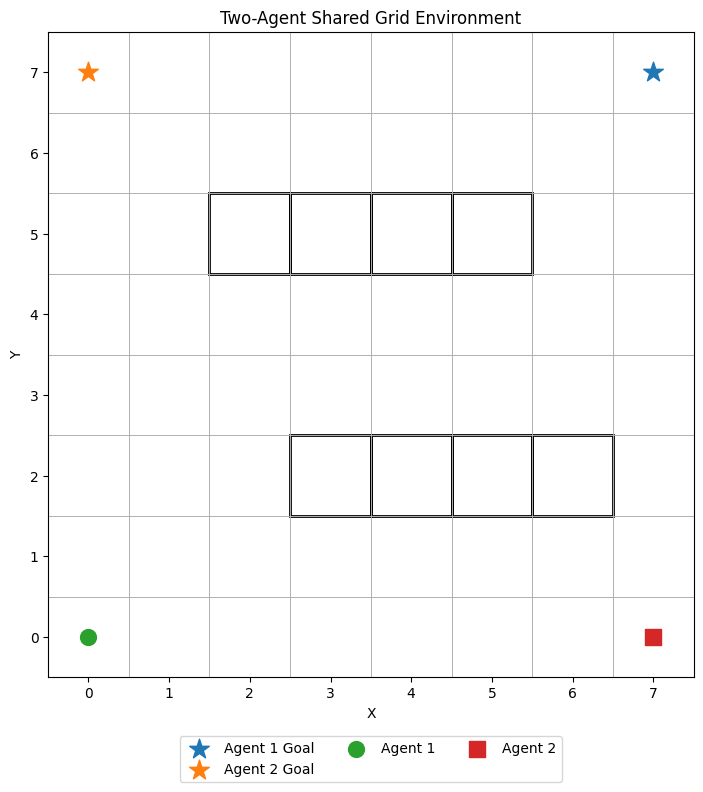

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import imageio.v2 as imageio
from IPython.display import display, Image

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)

GRID_W = 8
GRID_H = 8

AGENT1_START = (0, 0)
AGENT1_GOAL  = (7, 7)

AGENT2_START = (7, 0)
AGENT2_GOAL  = (0, 7)

OBSTACLES = {
    (2, 5), (3, 5), (4, 5), (5, 5),
    (3, 2), (4, 2), (5, 2), (6, 2)
}

def draw_environment(
    pos1=AGENT1_START,
    pos2=AGENT2_START,
    path1=None,
    path2=None,
    title="Two-Agent Shared Grid Environment"
):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(-0.5, GRID_H - 0.5)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(-0.5, GRID_W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_H, 1), minor=True)
    ax.grid(which="minor", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    for x, y in OBSTACLES:
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, linewidth=2))

    ax.scatter(*AGENT1_GOAL, marker="*", s=220, label="Agent 1 Goal")
    ax.scatter(*AGENT2_GOAL, marker="*", s=220, label="Agent 2 Goal")
    ax.scatter(*pos1, marker="o", s=130, label="Agent 1")
    ax.scatter(*pos2, marker="s", s=130, label="Agent 2")

    if path1 is not None:
        ax.plot([p[0] for p in path1], [p[1] for p in path1],
                linewidth=2.5, label="Agent 1 Path")

    if path2 is not None:
        ax.plot([p[0] for p in path2], [p[1] for p in path2],
                linewidth=2.5, label="Agent 2 Path")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)
    plt.tight_layout()
    plt.show()

draw_environment()

# 8. State from Each Agent's Perspective

Each physical position has

$$
8\times8=64
$$

possibilities.

If each agent observes both robot positions, the complete position pair gives

$$
64\times64=4096
$$

possible encoded joint-position states.

For Agent 1,

$$
o_1=(p_1,p_2).
$$

For Agent 2,

$$
o_2=(p_2,p_1).
$$

This own-position-first ordering lets each learner interpret the first component as "me" and the second as "the other agent."

The allocated table contains all 4096 combinations for simplicity, although obstacle cells, identical-position states, and some other combinations are not physically reachable.

# 9. Action Space and Joint Action Space

Each agent has five actions:

| Action | Meaning |
|---:|---|
| 0 | Up |
| 1 | Down |
| 2 | Left |
| 3 | Right |
| 4 | Stay |

Therefore,

$$
|\mathcal A_1|
=
|\mathcal A_2|
=
5.
$$

Because both agents act at the same time, the joint action is

$$
\mathbf A_t=(A_t^1,A_t^2).
$$

The joint action space contains

$$
|\mathcal A_1\times\mathcal A_2|
=
5\times5
=
25
$$

possible action combinations.

In [2]:
ACTION_NAMES = ["Up", "Down", "Left", "Right", "Stay"]

ACTION_DELTAS = {
    0: (0, 1),
    1: (0, -1),
    2: (-1, 0),
    3: (1, 0),
    4: (0, 0)
}

display(pd.DataFrame({
    "Action": range(5),
    "Meaning": ACTION_NAMES
}))

,Action,Meaning
0,0,Up
1,1,Down
2,2,Left
3,3,Right
4,4,Stay


# 10. Reward Function

Each active agent receives

$$
r_i=
\begin{cases}
+30, & \text{if Agent }i\text{ reaches its goal},\\
-10, & \text{for an agent-to-agent collision},\\
-5, & \text{for an invalid boundary/obstacle move},\\
-1, & \text{for an ordinary valid step}.
\end{cases}
$$

Once an agent reaches its own goal, it remains there and no longer receives the ordinary step penalty.

The two rewards do not have to be identical in the same time step.

For example, Agent 1 could make a normal move and receive

$$
r_1=-1,
$$

while Agent 2 attempts an invalid move and receives

$$
r_2=-5.
$$

The rewards are separate but aligned with the cooperative objective of completing the episode safely.

# 11. Simultaneous Transition and Collision Rules

At time $t$:

1. Agent 1 selects $A_t^1$.
2. Agent 2 selects $A_t^2$.
3. Both proposed positions are calculated.
4. Boundary and static-obstacle violations are checked.
5. Agent-to-agent conflicts are checked.
6. Both positions are updated together.
7. Each agent receives its own reward.

Two inter-agent conflicts are prevented.

### Vertex collision

Both agents try to occupy the same next cell:

$$
p_{t+1}^1=p_{t+1}^2.
$$

### Edge-swap collision

The agents attempt to exchange positions:

$$
p_{t+1}^1=p_t^2
\quad\text{and}\quad
p_{t+1}^2=p_t^1.
$$

# 12. Independent Q-Learning

We use **Independent Q-Learning (IQL)**.

Agent 1 learns

$$
Q_1(o_1,a_1)
$$

and Agent 2 learns

$$
Q_2(o_2,a_2).
$$

For Agent 1,

$$
Q_1(o_t^1,a_t^1)
\leftarrow
Q_1(o_t^1,a_t^1)
+
\alpha
\left[
r_{t+1}^1
+
\gamma
\max_{a_1'}
Q_1(o_{t+1}^1,a_1')
-
Q_1(o_t^1,a_t^1)
\right].
$$

For Agent 2,

$$
Q_2(o_t^2,a_t^2)
\leftarrow
Q_2(o_t^2,a_t^2)
+
\alpha
\left[
r_{t+1}^2
+
\gamma
\max_{a_2'}
Q_2(o_{t+1}^2,a_2')
-
Q_2(o_t^2,a_t^2)
\right].
$$

The TD errors are

$$
\delta_t^1
=
r_{t+1}^1
+
\gamma\max_{a_1'}Q_1(o_{t+1}^1,a_1')
-
Q_1(o_t^1,a_t^1)
$$

and

$$
\delta_t^2
=
r_{t+1}^2
+
\gamma\max_{a_2'}Q_2(o_{t+1}^2,a_2')
-
Q_2(o_t^2,a_t^2).
$$

# 13. Why Multi-Agent Learning Is Harder

In a single-agent environment, the transition model can be written as

$$
P(S_{t+1}\mid S_t,A_t).
$$

Here, the next state depends on both decisions:

$$
P(S_{t+1}\mid S_t,A_t^1,A_t^2).
$$

From Agent 1's perspective, Agent 2 is also learning and continually changing its policy.

Therefore, even if Agent 1 repeats the same action in the same observed situation, the resulting transition can change because Agent 2 may behave differently.

This creates **non-stationarity**.

Other difficulties include:

- larger state spaces;
- larger joint action spaces;
- coordination;
- collision avoidance;
- credit assignment;
- multiple possible stable behaviors.

# 14. State Encoding and Q-Table Size

Each physical position is encoded by

$$
p=yW+x.
$$

Then

$$
s_1=p_1(64)+p_2
$$

for Agent 1, and

$$
s_2=p_2(64)+p_1
$$

for Agent 2.

Each agent has a Q-table of size

$$
4096\times5.
$$

Therefore, each agent stores

$$
20{,}480
$$

Q-values, and both agents together store

$$
40{,}960.
$$

In [3]:
N_POSITIONS = GRID_W * GRID_H
N_STATES = N_POSITIONS * N_POSITIONS
N_ACTIONS = len(ACTION_NAMES)

def position_id(pos):
    x, y = pos
    return y * GRID_W + x

def encode_state(own_pos, other_pos):
    own_id = position_id(own_pos)
    other_id = position_id(other_pos)
    return own_id * N_POSITIONS + other_id

print("Positions per agent:", N_POSITIONS)
print("Encoded states per agent:", N_STATES)
print("Q-table shape per agent:", (N_STATES, N_ACTIONS))
print("Q-values per agent:", N_STATES * N_ACTIONS)
print("Q-values across both agents:", 2 * N_STATES * N_ACTIONS)

Positions per agent: 64
Encoded states per agent: 4096
Q-table shape per agent: (4096, 5)
Q-values per agent: 20480
Q-values across both agents: 40960


# 15. Environment Step Function

In [4]:
def candidate_position(pos, action):
    dx, dy = ACTION_DELTAS[action]
    return (pos[0] + dx, pos[1] + dy)

def is_valid_static(pos):
    x, y = pos
    return (
        0 <= x < GRID_W and
        0 <= y < GRID_H and
        pos not in OBSTACLES
    )

def multi_agent_step(pos1, pos2, action1, action2, done1=False, done2=False):
    reward1 = 0.0 if done1 else -1.0
    reward2 = 0.0 if done2 else -1.0

    proposed1 = pos1 if done1 else candidate_position(pos1, action1)
    proposed2 = pos2 if done2 else candidate_position(pos2, action2)

    invalid1 = (not done1) and (not is_valid_static(proposed1))
    invalid2 = (not done2) and (not is_valid_static(proposed2))

    if invalid1:
        proposed1 = pos1
        reward1 = -5.0

    if invalid2:
        proposed2 = pos2
        reward2 = -5.0

    same_cell_collision = (
        proposed1 == proposed2 and
        not (done1 and done2)
    )

    swap_collision = (
        proposed1 == pos2 and
        proposed2 == pos1 and
        pos1 != pos2
    )

    collision = same_cell_collision or swap_collision

    if collision:
        if not done1:
            proposed1 = pos1
            reward1 = -10.0
        if not done2:
            proposed2 = pos2
            reward2 = -10.0

    next_pos1 = proposed1
    next_pos2 = proposed2

    reached1 = done1 or (next_pos1 == AGENT1_GOAL)
    reached2 = done2 or (next_pos2 == AGENT2_GOAL)

    newly_reached1 = (not done1) and reached1
    newly_reached2 = (not done2) and reached2

    if newly_reached1:
        reward1 = 30.0

    if newly_reached2:
        reward2 = 30.0

    info = {
        "invalid1": invalid1,
        "invalid2": invalid2,
        "collision": collision,
        "newly_reached1": newly_reached1,
        "newly_reached2": newly_reached2
    }

    return next_pos1, next_pos2, reward1, reward2, reached1, reached2, info

# 16. $\epsilon$-Greedy Exploration

Each agent independently balances exploration and exploitation:

$$
A_t^i=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon,\\
\arg\max_a Q_i(o_t^i,a), & \text{with probability }1-\epsilon.
\end{cases}
$$

We decay $\epsilon$ over training:

$$
\epsilon_e
=
\max
\left(
\epsilon_{\min},
\epsilon_0\lambda^e
\right).
$$

In [5]:
def epsilon_greedy(q_table, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(N_ACTIONS))

    best_actions = np.flatnonzero(
        q_table[state] == np.max(q_table[state])
    )
    return int(rng.choice(best_actions))

def epsilon_schedule(
    episode,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.999
):
    return max(
        epsilon_min,
        epsilon_start * (epsilon_decay ** episode)
    )

# 17. One-Step Q-Learning Update

For either agent,

$$
\text{target}
=
r+\gamma\max_{a'}Q(s',a')
$$

for a nonterminal transition.

The TD error is

$$
\delta
=
\text{target}-Q(s,a),
$$

and the update is

$$
Q(s,a)
\leftarrow
Q(s,a)+\alpha\delta.
$$

At an agent's terminal goal state,

$$
\text{target}=r.
$$

In [6]:
def update_q_value(q_table, state, action, reward, next_state, done, alpha, gamma):
    old_q = q_table[state, action]

    if done:
        target = reward
    else:
        target = reward + gamma * np.max(q_table[next_state])

    td_error = target - old_q
    new_q = old_q + alpha * td_error
    q_table[state, action] = new_q

    return old_q, target, td_error, new_q

# 18. Manual Q-Value Calculation for Both Agents

Assume

$$
\alpha=0.1,
\qquad
\gamma=0.95.
$$

## Agent 1

Suppose

$$
Q_1(o_1,a_1)=2,
$$

$$
r_1=-1,
$$

and

$$
\max_a Q_1(o'_1,a)=5.
$$

Then

$$
\begin{aligned}
Q_1(o_1,a_1)
&\leftarrow
2+
0.1[-1+0.95(5)-2]\\
&=
2+0.1(1.75)\\
&=
\boxed{2.175}.
\end{aligned}
$$

## Agent 2

Suppose Agent 2 receives a collision penalty:

$$
Q_2(o_2,a_2)=1,
$$

$$
r_2=-10,
$$

and

$$
\max_a Q_2(o'_2,a)=4.
$$

Then

$$
\begin{aligned}
Q_2(o_2,a_2)
&\leftarrow
1+
0.1[-10+0.95(4)-1]\\
&=
1+0.1(-7.2)\\
&=
\boxed{0.28}.
\end{aligned}
$$

This shows that both agents can update different Q-values from the same environment time step.

# 19. Training Algorithm

```text
Initialize Q1(s,a) = 0
Initialize Q2(s,a) = 0

For each episode:

    Reset both agents

    Repeat:

        Observe:
            o1 = (Agent 1 position, Agent 2 position)
            o2 = (Agent 2 position, Agent 1 position)

        Choose:
            a1 using epsilon-greedy from Q1
            a2 using epsilon-greedy from Q2

        Execute a1 and a2 simultaneously

        Observe:
            r1, r2
            next positions
            collision / invalid-move information

        Construct next observations:
            o1'
            o2'

        Update Q1

        Update Q2

    Until both agents reach their goals
    or the episode step limit is reached
```

# 20. Training Configuration

The same learning parameters are used for both agents:

$$
\alpha=0.10,
\qquad
\gamma=0.95.
$$

Training uses 6000 episodes and an $\epsilon$-greedy exploration schedule.

In [7]:
EPISODES = 6000
MAX_STEPS = 150
ALPHA = 0.10
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.999
SEED = 42

print("Episodes:", EPISODES)
print("Maximum steps per episode:", MAX_STEPS)
print("Alpha:", ALPHA)
print("Gamma:", GAMMA)
print("Initial epsilon:", EPSILON_START)
print("Minimum epsilon:", EPSILON_MIN)
print("Epsilon decay:", EPSILON_DECAY)

Episodes: 6000
Maximum steps per episode: 150
Alpha: 0.1
Gamma: 0.95
Initial epsilon: 1.0
Minimum epsilon: 0.05
Epsilon decay: 0.999


# 21. Train Both Agents and Record Learning

In addition to the usual performance metrics, the training function records:

- the first **60 Q-updates for Agent 1**;
- the first **60 Q-updates for Agent 2**;
- Q-table snapshots at selected episodes;
- individual Q-table change for convergence analysis.

In [8]:
def train_multi_agent_q_learning(
    episodes=EPISODES,
    max_steps=MAX_STEPS,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
    seed=SEED,
    log_limit=60,
    snapshot_episodes=(0, 500, 2000, 6000)
):
    rng = np.random.default_rng(seed)

    q1 = np.zeros((N_STATES, N_ACTIONS), dtype=np.float32)
    q2 = np.zeros((N_STATES, N_ACTIONS), dtype=np.float32)

    rewards1 = []
    rewards2 = []
    steps_history = []
    success1_history = []
    success2_history = []
    joint_success_history = []
    collision_history = []
    invalid1_history = []
    invalid2_history = []
    delta1_history = []
    delta2_history = []

    log1 = []
    log2 = []
    update_count1 = 0
    update_count2 = 0

    snapshots1 = {0: q1.copy()}
    snapshots2 = {0: q2.copy()}

    for episode in range(episodes):
        epsilon = epsilon_schedule(
            episode,
            epsilon_start,
            epsilon_min,
            epsilon_decay
        )

        pos1 = AGENT1_START
        pos2 = AGENT2_START
        done1 = False
        done2 = False

        total_reward1 = 0.0
        total_reward2 = 0.0
        collisions = 0
        invalid1_count = 0
        invalid2_count = 0

        q1_before = q1.copy()
        q2_before = q2.copy()

        for step in range(1, max_steps + 1):
            s1 = encode_state(pos1, pos2)
            s2 = encode_state(pos2, pos1)

            action1 = 4 if done1 else epsilon_greedy(q1, s1, epsilon, rng)
            action2 = 4 if done2 else epsilon_greedy(q2, s2, epsilon, rng)

            old_pos1, old_pos2 = pos1, pos2

            (
                next_pos1,
                next_pos2,
                reward1,
                reward2,
                next_done1,
                next_done2,
                info
            ) = multi_agent_step(
                pos1,
                pos2,
                action1,
                action2,
                done1,
                done2
            )

            s1_next = encode_state(next_pos1, next_pos2)
            s2_next = encode_state(next_pos2, next_pos1)

            if not done1:
                old_q1, target1, td1, new_q1 = update_q_value(
                    q1, s1, action1, reward1, s1_next,
                    next_done1, alpha, gamma
                )

                update_count1 += 1
                if update_count1 <= log_limit:
                    log1.append([
                        update_count1, episode + 1, step,
                        old_pos1, old_pos2, s1,
                        ACTION_NAMES[action1], reward1,
                        next_pos1, next_pos2, s1_next,
                        old_q1, target1, td1, new_q1,
                        epsilon, info["collision"], info["invalid1"]
                    ])

            if not done2:
                old_q2, target2, td2, new_q2 = update_q_value(
                    q2, s2, action2, reward2, s2_next,
                    next_done2, alpha, gamma
                )

                update_count2 += 1
                if update_count2 <= log_limit:
                    log2.append([
                        update_count2, episode + 1, step,
                        old_pos2, old_pos1, s2,
                        ACTION_NAMES[action2], reward2,
                        next_pos2, next_pos1, s2_next,
                        old_q2, target2, td2, new_q2,
                        epsilon, info["collision"], info["invalid2"]
                    ])

            total_reward1 += reward1
            total_reward2 += reward2
            collisions += int(info["collision"])
            invalid1_count += int(info["invalid1"])
            invalid2_count += int(info["invalid2"])

            pos1, pos2 = next_pos1, next_pos2
            done1, done2 = next_done1, next_done2

            if done1 and done2:
                break

        rewards1.append(total_reward1)
        rewards2.append(total_reward2)
        steps_history.append(step)
        success1_history.append(int(done1))
        success2_history.append(int(done2))
        joint_success_history.append(int(done1 and done2))
        collision_history.append(collisions)
        invalid1_history.append(invalid1_count)
        invalid2_history.append(invalid2_count)

        delta1_history.append(np.max(np.abs(q1 - q1_before)))
        delta2_history.append(np.max(np.abs(q2 - q2_before)))

        completed_episode = episode + 1
        if completed_episode in snapshot_episodes:
            snapshots1[completed_episode] = q1.copy()
            snapshots2[completed_episode] = q2.copy()

    columns = [
        "Update", "Episode", "Step",
        "Own Position", "Other Position", "State ID",
        "Action", "Reward",
        "Next Own Position", "Next Other Position", "Next State ID",
        "Old Q", "TD Target", "TD Error", "New Q",
        "Epsilon", "Collision", "Invalid Move"
    ]

    history = {
        "reward1": np.array(rewards1),
        "reward2": np.array(rewards2),
        "steps": np.array(steps_history),
        "success1": np.array(success1_history),
        "success2": np.array(success2_history),
        "joint_success": np.array(joint_success_history),
        "collisions": np.array(collision_history),
        "invalid1": np.array(invalid1_history),
        "invalid2": np.array(invalid2_history),
        "delta1": np.array(delta1_history),
        "delta2": np.array(delta2_history)
    }

    return (
        q1, q2, history,
        pd.DataFrame(log1, columns=columns),
        pd.DataFrame(log2, columns=columns),
        snapshots1, snapshots2
    )

q1, q2, history, log1, log2, snapshots1, snapshots2 = train_multi_agent_q_learning()

print("Training complete.")
print("Final 100-episode Agent 1 success:", history["success1"][-100:].mean())
print("Final 100-episode Agent 2 success:", history["success2"][-100:].mean())
print("Final 100-episode joint success:", history["joint_success"][-100:].mean())
print("Final 100-episode mean collisions:", history["collisions"][-100:].mean())

Training complete.
Final 100-episode Agent 1 success: 1.0
Final 100-episode Agent 2 success: 1.0
Final 100-episode joint success: 1.0
Final 100-episode mean collisions: 0.0


# 19. First 60 Q-Updates — Agent 1

Each row shows exactly how one entry of Agent 1's Q-table changes.

In [9]:
display(log1)

,Update,Episode,Step,Own Position,Other Position,State ID,Action,Reward,Next Own Position,Next Other Position,Next State ID,Old Q,TD Target,TD Error,New Q,Epsilon,Collision,Invalid Move
0,1,1,1,"(0, 0)","(7, 0)",7,Right,-1.0,"(1, 0)","(6, 0)",70,0.00,-1.0,-1.00,-0.100,1.0,False,False
1,2,1,2,"(1, 0)","(6, 0)",70,Down,-5.0,"(1, 0)","(6, 1)",78,0.00,-5.0,-5.00,-0.500,1.0,False,True
2,3,1,3,"(1, 0)","(6, 1)",78,Right,-1.0,"(2, 0)","(7, 1)",143,0.00,-1.0,-1.00,-0.100,1.0,False,False
3,4,1,4,"(2, 0)","(7, 1)",143,Left,-1.0,"(1, 0)","(7, 0)",71,0.00,-1.0,-1.00,-0.100,1.0,False,False
4,5,1,5,"(1, 0)","(7, 0)",71,Left,-1.0,"(0, 0)","(7, 0)",7,0.00,-1.0,-1.00,-0.100,1.0,False,False
5,6,1,6,"(0, 0)","(7, 0)",7,Up,-1.0,"(0, 1)","(6, 0)",518,0.00,-1.0,-1.00,-0.100,1.0,False,False
6,7,1,7,"(0, 1)","(6, 0)",518,Down,-1.0,"(0, 0)","(7, 0)",7,0.00,-1.0,-1.00,-0.100,1.0,False,False
7,8,1,8,"(0, 0)","(7, 0)",7,Up,-1.0,"(0, 1)","(7, 0)",519,-0.10,-1.0,-0.90,-0.190,1.0,False,False
8,9,1,9,"(0, 1)","(7, 0)",519,Right,-1.0,"(1, 1)","(7, 1)",591,0.00,-1.0,-1.00,-0.100,1.0,False,False
9,10,1,10,"(1, 1)","(7, 1)",591,Left,-1.0,"(0, 1)","(7, 2)",535,0.00,-1.0,-1.00,-0.100,1.0,False,False


# 20. First 60 Q-Updates — Agent 2

This table gives the same information from Agent 2's perspective.

In [10]:
display(log2)

,Update,Episode,Step,Own Position,Other Position,State ID,Action,Reward,Next Own Position,Next Other Position,Next State ID,Old Q,TD Target,TD Error,New Q,Epsilon,Collision,Invalid Move
0,1,1,1,"(7, 0)","(0, 0)",448,Left,-1.0,"(6, 0)","(1, 0)",385,0.0,-1.0,-1.0,-0.10,1.0,False,False
1,2,1,2,"(6, 0)","(1, 0)",385,Up,-1.0,"(6, 1)","(1, 0)",897,0.0,-1.0,-1.0,-0.10,1.0,False,False
2,3,1,3,"(6, 1)","(1, 0)",897,Right,-1.0,"(7, 1)","(2, 0)",962,0.0,-1.0,-1.0,-0.10,1.0,False,False
3,4,1,4,"(7, 1)","(2, 0)",962,Down,-1.0,"(7, 0)","(1, 0)",449,0.0,-1.0,-1.0,-0.10,1.0,False,False
4,5,1,5,"(7, 0)","(1, 0)",449,Stay,-1.0,"(7, 0)","(0, 0)",448,0.0,-1.0,-1.0,-0.10,1.0,False,False
5,6,1,6,"(7, 0)","(0, 0)",448,Left,-1.0,"(6, 0)","(0, 1)",392,-0.1,-1.0,-0.9,-0.19,1.0,False,False
6,7,1,7,"(6, 0)","(0, 1)",392,Right,-1.0,"(7, 0)","(0, 0)",448,0.0,-1.0,-1.0,-0.10,1.0,False,False
7,8,1,8,"(7, 0)","(0, 0)",448,Stay,-1.0,"(7, 0)","(0, 1)",456,0.0,-1.0,-1.0,-0.10,1.0,False,False
8,9,1,9,"(7, 0)","(0, 1)",456,Up,-1.0,"(7, 1)","(1, 1)",969,0.0,-1.0,-1.0,-0.10,1.0,False,False
9,10,1,10,"(7, 1)","(1, 1)",969,Up,-1.0,"(7, 2)","(0, 1)",1480,0.0,-1.0,-1.0,-0.10,1.0,False,False


## Detailed Numerical Calculations from the Recorded Training Updates

The 60-update tables already contain the complete numerical information needed to audit learning.

For every nonterminal update, each agent uses

$$
\text{TD target}_i
=
r_i+\gamma\max_{a'}Q_i(o'_i,a')
$$

followed by

$$
\delta_i
=
\text{TD target}_i-Q_i(o_i,a_i)
$$

and

$$
Q_i(o_i,a_i)
\leftarrow
Q_i(o_i,a_i)+\alpha\delta_i.
$$

The next cell rewrites several recorded updates as explicit numerical calculations so that the connection between the equation and the code is visible.

In [11]:
def calculation_table(log_df, agent_name, alpha=ALPHA, n=10):
    rows = []

    for _, r in log_df.head(n).iterrows():
        old_q = float(r["Old Q"])
        target = float(r["TD Target"])
        td_error = float(r["TD Error"])
        new_q = float(r["New Q"])

        equation = (
            f"{old_q:.4f} + {alpha:.2f} × "
            f"({target:.4f} - {old_q:.4f}) = {new_q:.4f}"
        )

        rows.append({
            "Agent": agent_name,
            "Update": int(r["Update"]),
            "State ID": int(r["State ID"]),
            "Action": r["Action"],
            "Reward": float(r["Reward"]),
            "Old Q": old_q,
            "TD Target": target,
            "TD Error": td_error,
            "Calculation": equation,
            "New Q": new_q
        })

    return pd.DataFrame(rows)

print("Agent 1 — sample numerical Q-learning calculations")
display(calculation_table(log1, "Agent 1"))

print("Agent 2 — sample numerical Q-learning calculations")
display(calculation_table(log2, "Agent 2"))

Agent 1 — sample numerical Q-learning calculations


,Agent,Update,State ID,Action,Reward,Old Q,TD Target,TD Error,Calculation,New Q
0,Agent 1,1,7,Right,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
1,Agent 1,2,70,Down,-5.0,0.0,-5.0,-5.0,0.0000 + 0.10 × (-5.0000 - 0.0000) = -0.5000,-0.50
2,Agent 1,3,78,Right,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
3,Agent 1,4,143,Left,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
4,Agent 1,5,71,Left,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
5,Agent 1,6,7,Up,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
6,Agent 1,7,518,Down,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
7,Agent 1,8,7,Up,-1.0,-0.1,-1.0,-0.9,-0.1000 + 0.10 × (-1.0000 - -0.1000) = -0.1900,-0.19
8,Agent 1,9,519,Right,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
9,Agent 1,10,591,Left,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10


Agent 2 — sample numerical Q-learning calculations


,Agent,Update,State ID,Action,Reward,Old Q,TD Target,TD Error,Calculation,New Q
0,Agent 2,1,448,Left,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
1,Agent 2,2,385,Up,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
2,Agent 2,3,897,Right,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
3,Agent 2,4,962,Down,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
4,Agent 2,5,449,Stay,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
5,Agent 2,6,448,Left,-1.0,-0.1,-1.0,-0.9,-0.1000 + 0.10 × (-1.0000 - -0.1000) = -0.1900,-0.19
6,Agent 2,7,392,Right,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
7,Agent 2,8,448,Stay,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
8,Agent 2,9,456,Up,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10
9,Agent 2,10,969,Up,-1.0,0.0,-1.0,-1.0,0.0000 + 0.10 × (-1.0000 - 0.0000) = -0.1000,-0.10


# 21. Individual Q-Tables

Each Q-table has shape

$$
4096\times5.
$$

The complete tables are exported to CSV.

For readability, the notebook displays Q-values for states encountered in the final greedy trajectory rather than printing all 4096 rows.

In [12]:
q1_df = pd.DataFrame(q1, columns=ACTION_NAMES)
q1_df.index.name = "State"

q2_df = pd.DataFrame(q2, columns=ACTION_NAMES)
q2_df.index.name = "State"

q1_df.to_csv("agent1_q_table.csv")
q2_df.to_csv("agent2_q_table.csv")

print("Agent 1 Q-table shape:", q1_df.shape)
print("Agent 2 Q-table shape:", q2_df.shape)
print("Complete tables saved as agent1_q_table.csv and agent2_q_table.csv")

Agent 1 Q-table shape: (4096, 5)
Agent 2 Q-table shape: (4096, 5)
Complete tables saved as agent1_q_table.csv and agent2_q_table.csv


# 22. Q-Table Evolution at the Initial Joint State

The initial observations are:

$$
o_1=((0,0),(7,0))
$$

for Agent 1, and

$$
o_2=((7,0),(0,0))
$$

for Agent 2.

The next tables show how the five action values at these initial states change across training snapshots.

In [13]:
initial_state1 = encode_state(AGENT1_START, AGENT2_START)
initial_state2 = encode_state(AGENT2_START, AGENT1_START)

snapshot_rows1 = []
snapshot_rows2 = []

for ep in sorted(snapshots1):
    row1 = {"Episode": ep}
    row1.update({ACTION_NAMES[a]: snapshots1[ep][initial_state1, a] for a in range(N_ACTIONS)})
    snapshot_rows1.append(row1)

for ep in sorted(snapshots2):
    row2 = {"Episode": ep}
    row2.update({ACTION_NAMES[a]: snapshots2[ep][initial_state2, a] for a in range(N_ACTIONS)})
    snapshot_rows2.append(row2)

print("Agent 1 — initial-state Q-values")
display(pd.DataFrame(snapshot_rows1).set_index("Episode"))

print("Agent 2 — initial-state Q-values")
display(pd.DataFrame(snapshot_rows2).set_index("Episode"))

Agent 1 — initial-state Q-values


,Up,Down,Left,Right,Stay
Episode,,,,,
0,0.000,0.000,0.000,0.000,0.000
500,-3.137,-7.503,-7.558,-3.131,-3.425
2000,-4.891,-8.936,-8.768,-4.901,-4.894
6000,-3.941,-8.696,-8.716,-5.357,-4.688


Agent 2 — initial-state Q-values


,Up,Down,Left,Right,Stay
Episode,,,,,
0,0.000,0.000,0.000,0.000,0.000
500,-3.102,-7.446,-3.077,-7.309,-3.536
2000,-5.014,-8.918,-5.017,-8.945,-5.017
6000,4.876,-4.397,-5.797,-4.431,-1.200


## Q-Value Evolution at the Initial State — Agent 1

The table above gives snapshots. The graph below shows the same information as action-value trajectories.

For the initial joint observation,

$$
o_1=((0,0),(7,0)),
$$

each line represents one action value

$$
Q_1(o_1,a).
$$

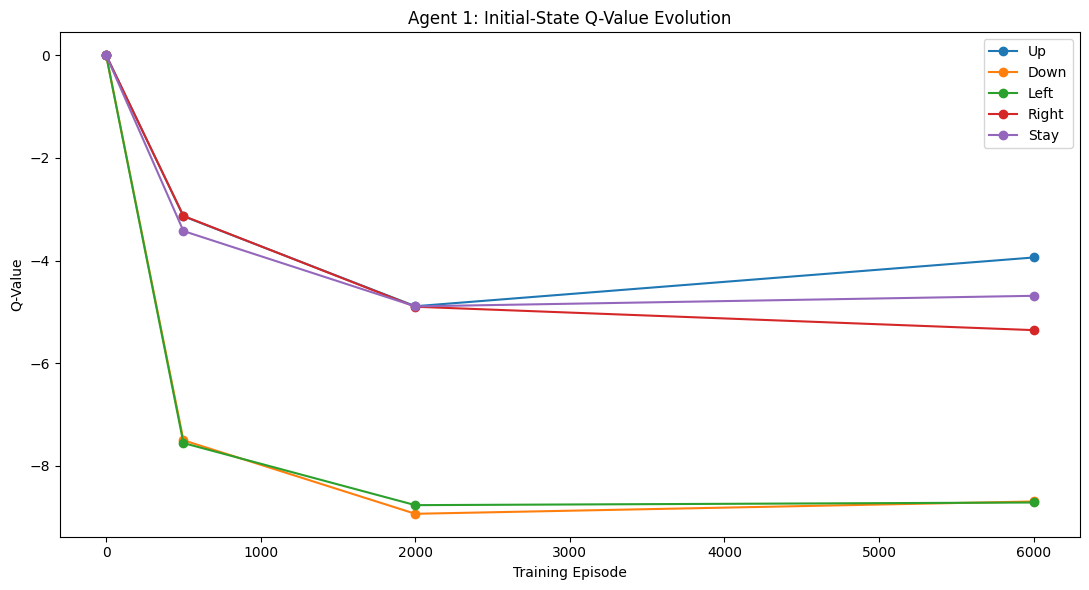

In [14]:
snapshot_df1 = pd.DataFrame(snapshot_rows1).set_index("Episode")

plt.figure(figsize=(11, 6))
for action in ACTION_NAMES:
    plt.plot(snapshot_df1.index, snapshot_df1[action], marker="o", label=action)

plt.xlabel("Training Episode")
plt.ylabel("Q-Value")
plt.title("Agent 1: Initial-State Q-Value Evolution")
plt.legend()
plt.tight_layout()
plt.show()

## Q-Value Evolution at the Initial State — Agent 2

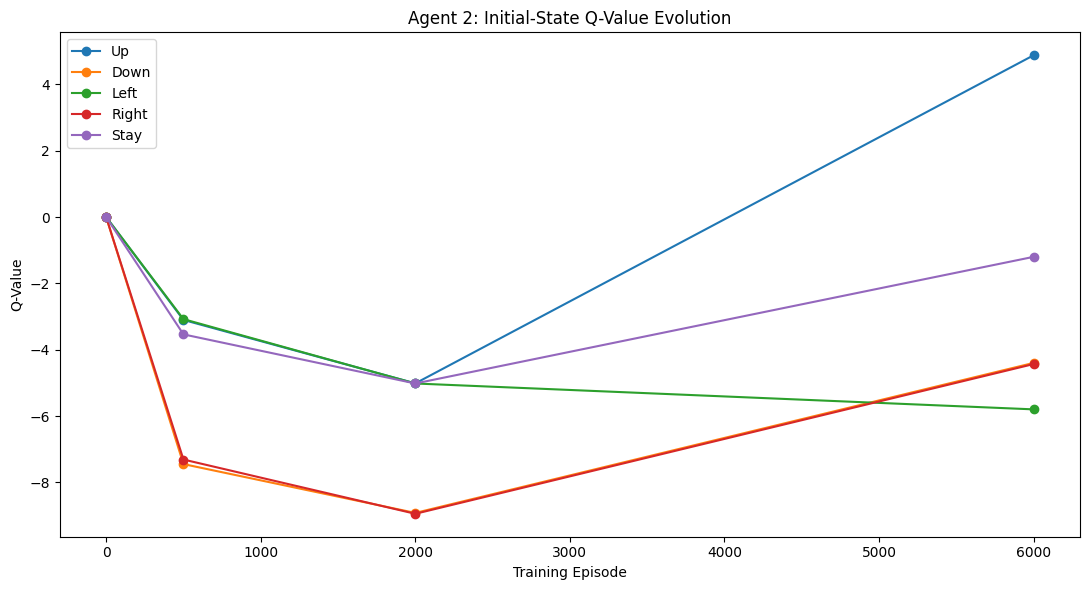

In [15]:
snapshot_df2 = pd.DataFrame(snapshot_rows2).set_index("Episode")

plt.figure(figsize=(11, 6))
for action in ACTION_NAMES:
    plt.plot(snapshot_df2.index, snapshot_df2[action], marker="o", label=action)

plt.xlabel("Training Episode")
plt.ylabel("Q-Value")
plt.title("Agent 2: Initial-State Q-Value Evolution")
plt.legend()
plt.tight_layout()
plt.show()

# 23. Reward vs. Episode — Agent 1

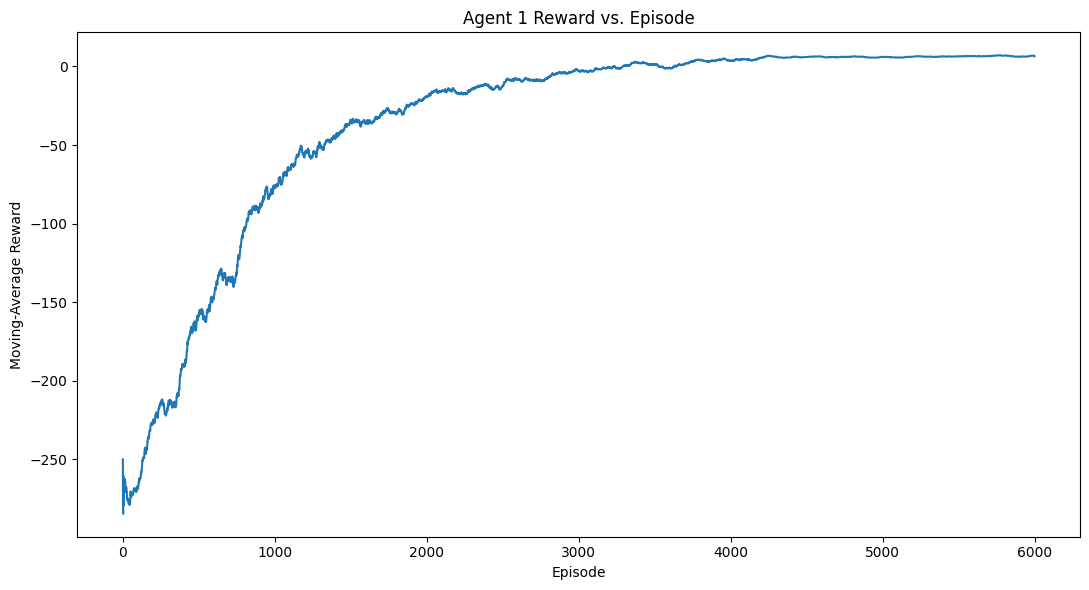

In [16]:
def moving_average(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean().to_numpy()

plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["reward1"], 100))
plt.xlabel("Episode")
plt.ylabel("Moving-Average Reward")
plt.title("Agent 1 Reward vs. Episode")
plt.tight_layout()
plt.show()

# 24. Reward vs. Episode — Agent 2

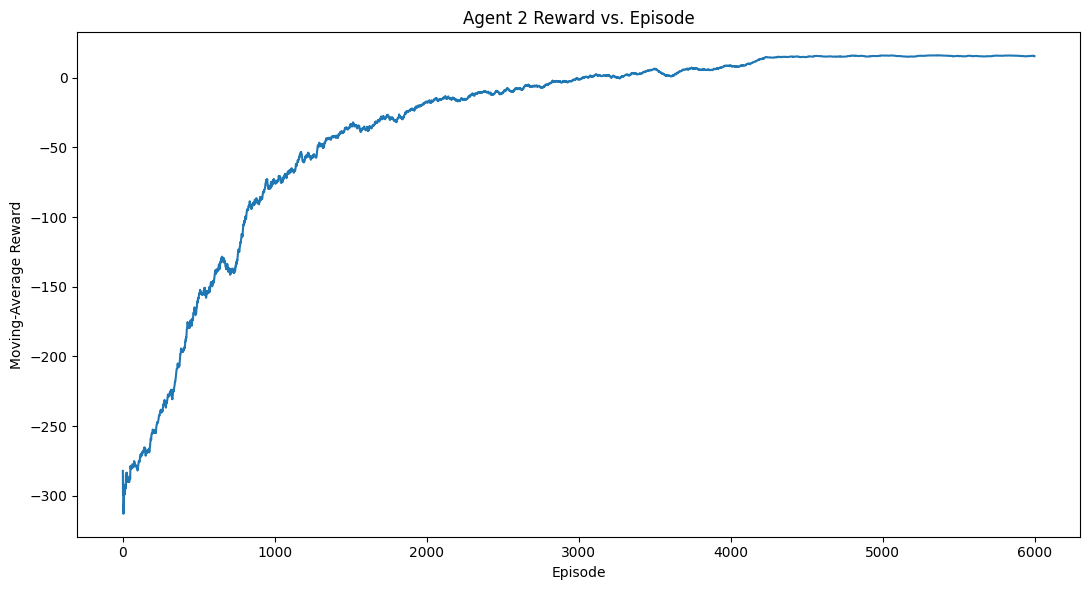

In [17]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["reward2"], 100))
plt.xlabel("Episode")
plt.ylabel("Moving-Average Reward")
plt.title("Agent 2 Reward vs. Episode")
plt.tight_layout()
plt.show()

# 25. Reward Comparison

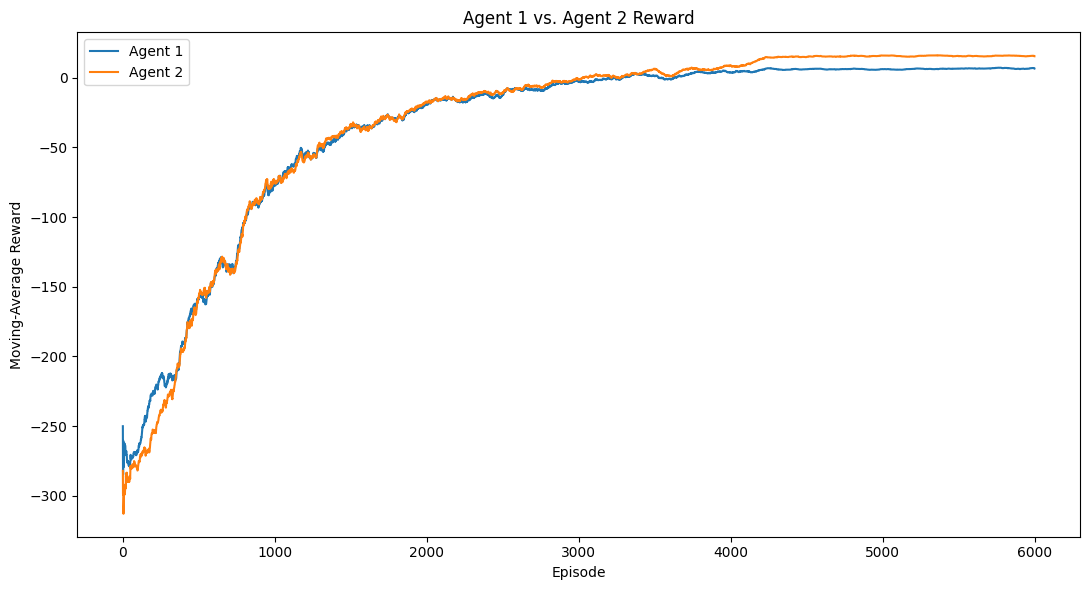

In [18]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["reward1"], 100), label="Agent 1")
plt.plot(moving_average(history["reward2"], 100), label="Agent 2")
plt.xlabel("Episode")
plt.ylabel("Moving-Average Reward")
plt.title("Agent 1 vs. Agent 2 Reward")
plt.legend()
plt.tight_layout()
plt.show()

# 26. Steps per Episode

Efficient coordination should reduce the number of steps needed for both agents to finish.

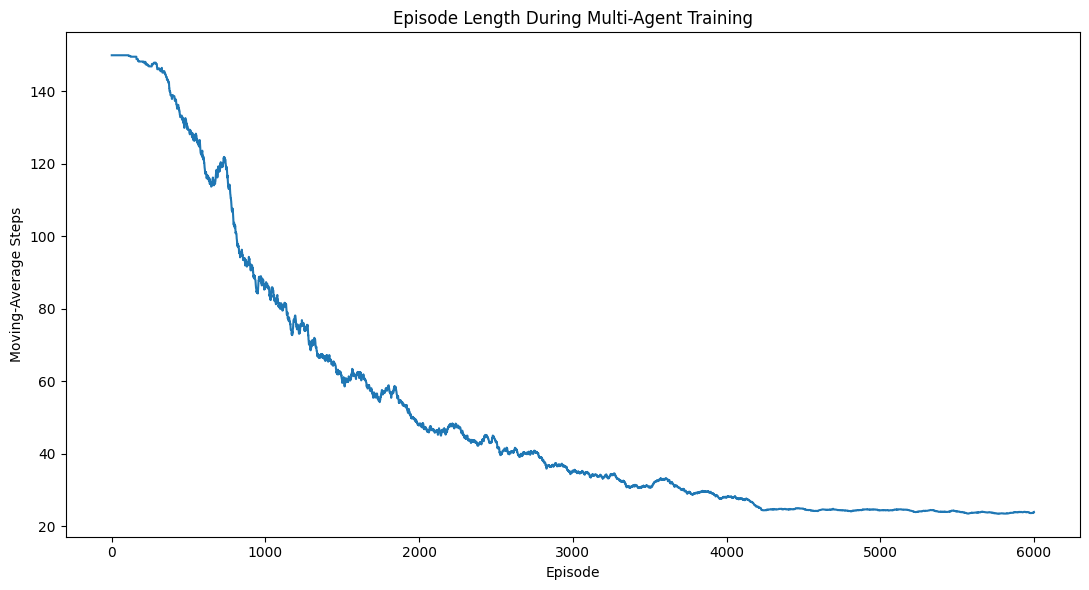

In [19]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["steps"], 100))
plt.xlabel("Episode")
plt.ylabel("Moving-Average Steps")
plt.title("Episode Length During Multi-Agent Training")
plt.tight_layout()
plt.show()

# 27. Individual and Joint Success Rates

Joint success requires

$$
\text{Agent 1 success}
\land
\text{Agent 2 success}.
$$

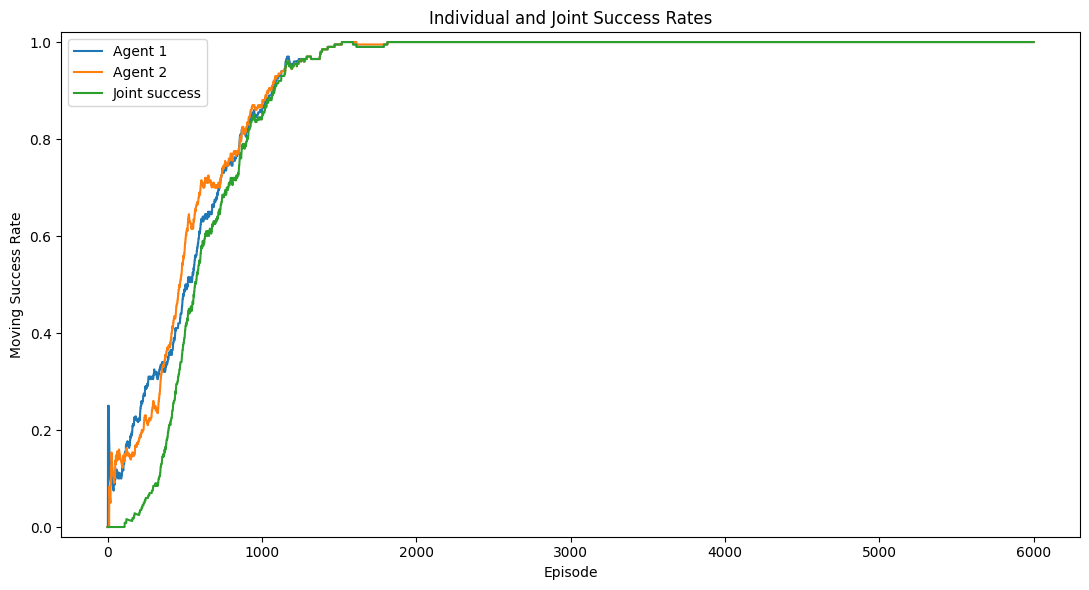

In [20]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["success1"], 200), label="Agent 1")
plt.plot(moving_average(history["success2"], 200), label="Agent 2")
plt.plot(moving_average(history["joint_success"], 200), label="Joint success")
plt.xlabel("Episode")
plt.ylabel("Moving Success Rate")
plt.title("Individual and Joint Success Rates")
plt.ylim(-0.02, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

# 28. Inter-Agent Collisions

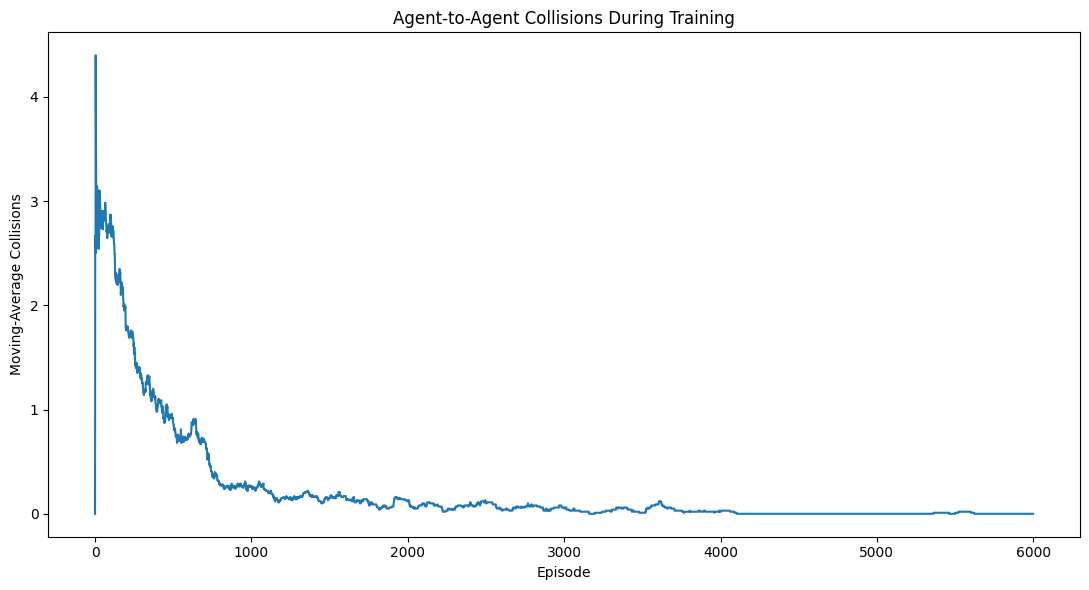

In [21]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["collisions"], 100))
plt.xlabel("Episode")
plt.ylabel("Moving-Average Collisions")
plt.title("Agent-to-Agent Collisions During Training")
plt.tight_layout()
plt.show()

# 29. Invalid Moves by Each Agent

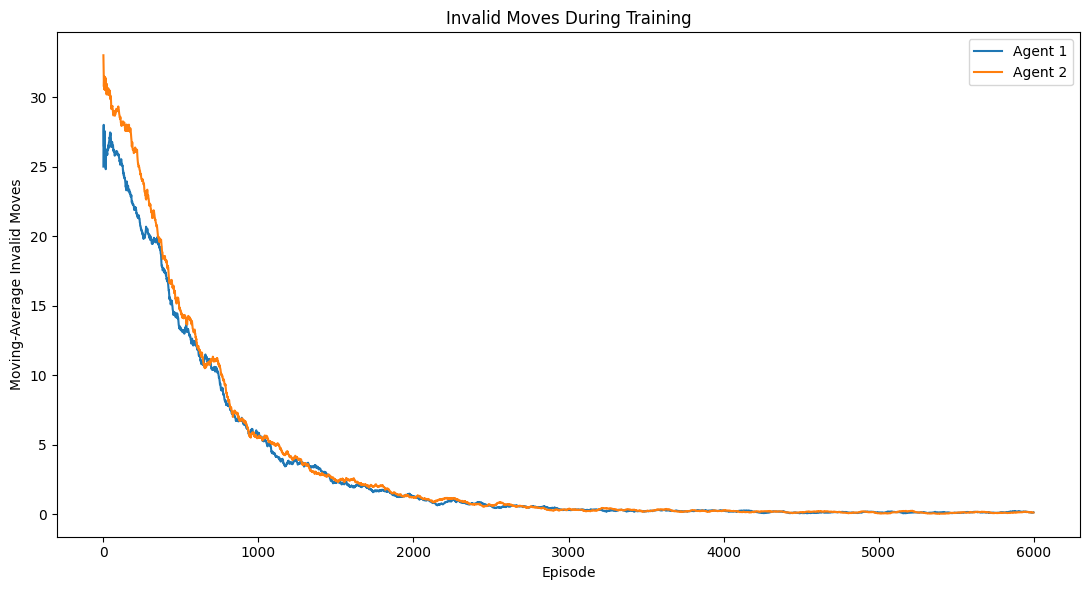

In [22]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["invalid1"], 100), label="Agent 1")
plt.plot(moving_average(history["invalid2"], 100), label="Agent 2")
plt.xlabel("Episode")
plt.ylabel("Moving-Average Invalid Moves")
plt.title("Invalid Moves During Training")
plt.legend()
plt.tight_layout()
plt.show()

# 30. Q-Table Convergence — Agent 1

For Agent 1,

$$
\Delta Q_1^{(e)}
=
\max_{s,a}
\left|
Q_1^{(e)}(s,a)
-
Q_1^{(e-1)}(s,a)
\right|.
$$

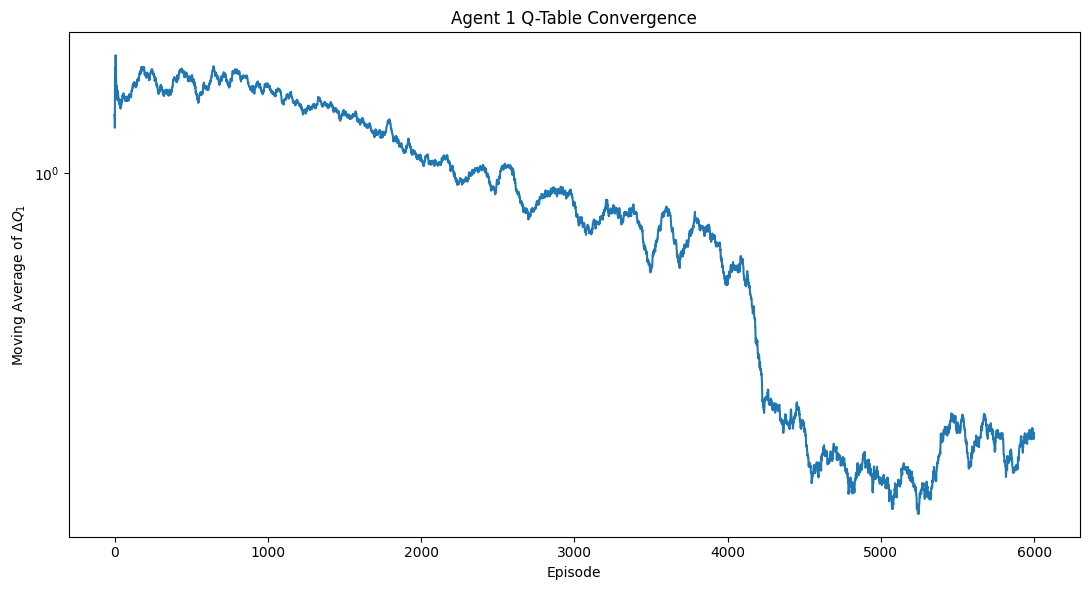

In [23]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["delta1"], 100))
plt.xlabel("Episode")
plt.ylabel(r"Moving Average of $\Delta Q_1$")
plt.title("Agent 1 Q-Table Convergence")
plt.yscale("symlog", linthresh=1e-5)
plt.tight_layout()
plt.show()

# 31. Q-Table Convergence — Agent 2

For Agent 2,

$$
\Delta Q_2^{(e)}
=
\max_{s,a}
\left|
Q_2^{(e)}(s,a)
-
Q_2^{(e-1)}(s,a)
\right|.
$$

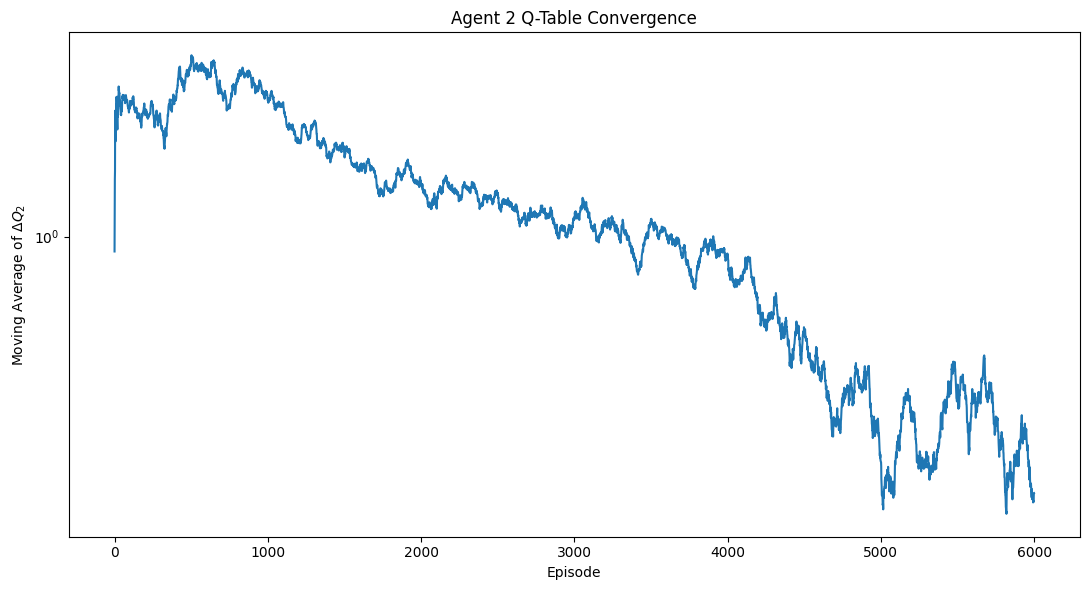

In [24]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["delta2"], 100))
plt.xlabel("Episode")
plt.ylabel(r"Moving Average of $\Delta Q_2$")
plt.title("Agent 2 Q-Table Convergence")
plt.yscale("symlog", linthresh=1e-5)
plt.tight_layout()
plt.show()

# 32. Q-Table Convergence Comparison

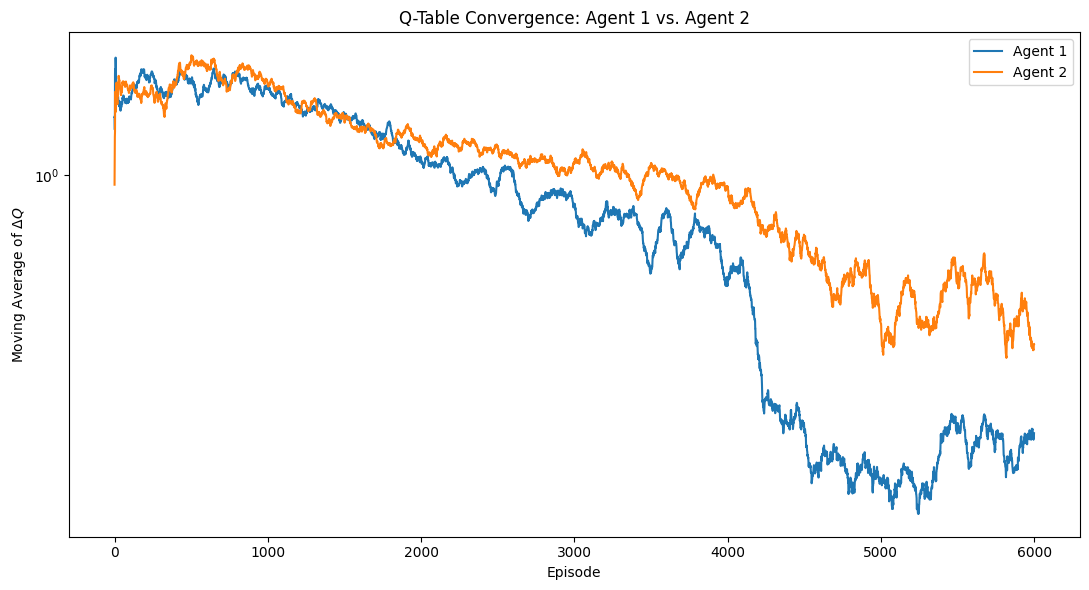

In [25]:
plt.figure(figsize=(11, 6))
plt.plot(moving_average(history["delta1"], 100), label="Agent 1")
plt.plot(moving_average(history["delta2"], 100), label="Agent 2")
plt.xlabel("Episode")
plt.ylabel(r"Moving Average of $\Delta Q$")
plt.title("Q-Table Convergence: Agent 1 vs. Agent 2")
plt.yscale("symlog", linthresh=1e-5)
plt.legend()
plt.tight_layout()
plt.show()

# 33. Greedy Evaluation

Training includes exploration.

For evaluation, both agents act greedily:

$$
A_t^i
=
\arg\max_a Q_i(o_t^i,a).
$$

In [26]:
def greedy_action(q_table, state, rng):
    best = np.flatnonzero(q_table[state] == np.max(q_table[state]))
    return int(rng.choice(best))

def evaluate_greedy_episode(q1, q2, max_steps=150, seed=2026):
    rng = np.random.default_rng(seed)

    pos1 = AGENT1_START
    pos2 = AGENT2_START
    done1 = False
    done2 = False

    path1 = [pos1]
    path2 = [pos2]
    trace = []

    total_reward1 = 0.0
    total_reward2 = 0.0
    total_collisions = 0

    for step in range(1, max_steps + 1):
        s1 = encode_state(pos1, pos2)
        s2 = encode_state(pos2, pos1)

        action1 = 4 if done1 else greedy_action(q1, s1, rng)
        action2 = 4 if done2 else greedy_action(q2, s2, rng)

        (
            next_pos1,
            next_pos2,
            reward1,
            reward2,
            next_done1,
            next_done2,
            info
        ) = multi_agent_step(
            pos1, pos2, action1, action2, done1, done2
        )

        trace.append([
            step,
            pos1, ACTION_NAMES[action1], reward1, next_pos1,
            pos2, ACTION_NAMES[action2], reward2, next_pos2,
            info["collision"]
        ])

        total_reward1 += reward1
        total_reward2 += reward2
        total_collisions += int(info["collision"])

        pos1, pos2 = next_pos1, next_pos2
        done1, done2 = next_done1, next_done2

        path1.append(pos1)
        path2.append(pos2)

        if done1 and done2:
            break

    trace_df = pd.DataFrame(
        trace,
        columns=[
            "Step",
            "Agent1 State", "Agent1 Action", "Agent1 Reward", "Agent1 Next State",
            "Agent2 State", "Agent2 Action", "Agent2 Reward", "Agent2 Next State",
            "Collision"
        ]
    )

    return {
        "steps": step,
        "agent1_success": done1,
        "agent2_success": done2,
        "joint_success": done1 and done2,
        "agent1_reward": total_reward1,
        "agent2_reward": total_reward2,
        "collisions": total_collisions,
        "path1": path1,
        "path2": path2,
        "trace": trace_df
    }

evaluation = evaluate_greedy_episode(q1, q2)

print("Joint success:", evaluation["joint_success"])
print("Steps:", evaluation["steps"])
print("Agent 1 reward:", evaluation["agent1_reward"])
print("Agent 2 reward:", evaluation["agent2_reward"])
print("Collisions:", evaluation["collisions"])

display(evaluation["trace"])

Joint success: True
Steps: 22
Agent 1 reward: 9.0
Agent 2 reward: 17.0
Collisions: 0


,Step,Agent1 State,Agent1 Action,Agent1 Reward,Agent1 Next State,Agent2 State,Agent2 Action,Agent2 Reward,Agent2 Next State,Collision
0,1,"(0, 0)",Up,-1.0,"(0, 1)","(7, 0)",Up,-1.0,"(7, 1)",False
1,2,"(0, 1)",Stay,-1.0,"(0, 1)","(7, 1)",Up,-1.0,"(7, 2)",False
2,3,"(0, 1)",Up,-1.0,"(0, 2)","(7, 2)",Up,-1.0,"(7, 3)",False
3,4,"(0, 2)",Right,-1.0,"(1, 2)","(7, 3)",Up,-1.0,"(7, 4)",False
4,5,"(1, 2)",Stay,-1.0,"(1, 2)","(7, 4)",Left,-1.0,"(6, 4)",False
5,6,"(1, 2)",Stay,-1.0,"(1, 2)","(6, 4)",Left,-1.0,"(5, 4)",False
6,7,"(1, 2)",Left,-1.0,"(0, 2)","(5, 4)",Left,-1.0,"(4, 4)",False
7,8,"(0, 2)",Right,-1.0,"(1, 2)","(4, 4)",Left,-1.0,"(3, 4)",False
8,9,"(1, 2)",Down,-1.0,"(1, 1)","(3, 4)",Left,-1.0,"(2, 4)",False
9,10,"(1, 1)",Right,-1.0,"(2, 1)","(2, 4)",Left,-1.0,"(1, 4)",False


# 34. Learned Q-Table Rows Along the Greedy Trajectory

These are the actual Agent 1 and Agent 2 Q-values encountered during the final greedy simulation.

In [27]:
states1 = []
states2 = []

for p1, p2 in zip(evaluation["path1"][:-1], evaluation["path2"][:-1]):
    states1.append(encode_state(p1, p2))
    states2.append(encode_state(p2, p1))

states1 = list(dict.fromkeys(states1))
states2 = list(dict.fromkeys(states2))

print("Agent 1 Q-values on greedy trajectory")
display(q1_df.loc[states1])

print("Agent 2 Q-values on greedy trajectory")
display(q2_df.loc[states2])

Agent 1 Q-values on greedy trajectory


,Up,Down,Left,Right,Stay
State,,,,,
7,-3.941,-8.696,-8.716,-5.357,-4.688
527,-4.059,-5.282,-7.533,-4.367,-2.950
535,-2.065,-4.651,-7.133,-3.119,-3.585
1055,-3.717,-3.253,-6.158,-1.042,-2.695
1127,-2.673,-1.708,-1.756,-3.391,0.011
1126,-1.128,-0.618,-1.487,-1.318,1.205
1125,1.166,0.824,2.525,-2.313,0.063
1060,-1.480,1.686,-3.015,3.856,0.603
1123,1.870,5.047,2.792,2.436,1.261


Agent 2 Q-values on greedy trajectory


,Up,Down,Left,Right,Stay
State,,,,,
448,4.876,-4.397,-5.797,-4.431,-1.200
968,6.297,-2.483,-2.735,-1.141,1.672
1480,7.628,1.069,-0.103,-1.511,2.452
2000,9.049,-1.860,0.996,0.838,3.868
2513,-2.046,3.923,10.429,3.243,5.207
2449,0.886,1.299,12.773,5.959,8.466
2385,5.053,1.654,14.664,7.500,8.006
2320,6.872,7.749,16.507,8.124,10.773
2257,5.915,6.541,18.444,12.239,11.470


# 35. Learned Paths of Both Agents

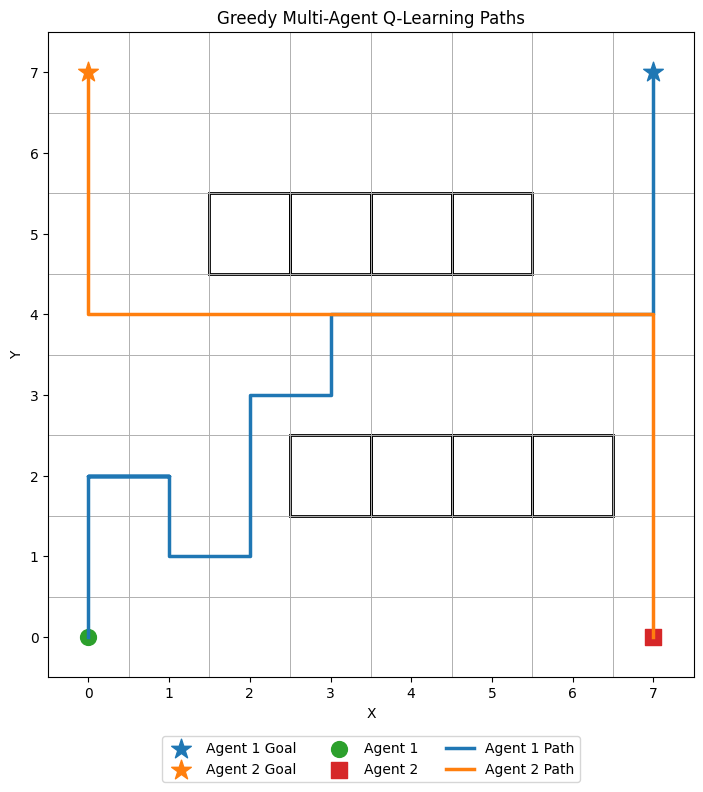

In [28]:
draw_environment(
    path1=evaluation["path1"],
    path2=evaluation["path2"],
    title="Greedy Multi-Agent Q-Learning Paths"
)

# 36. Agent 1 Value Map Conditioned on Agent 2's Position

A multi-agent Q-function depends on the other agent's position.

Therefore, there is no single $8\times8$ value map that completely represents the Q-table.

To visualize Agent 1, we hold Agent 2 at its start position and plot

$$
\max_a Q_1(o_1,a)
$$

for every possible Agent 1 position.

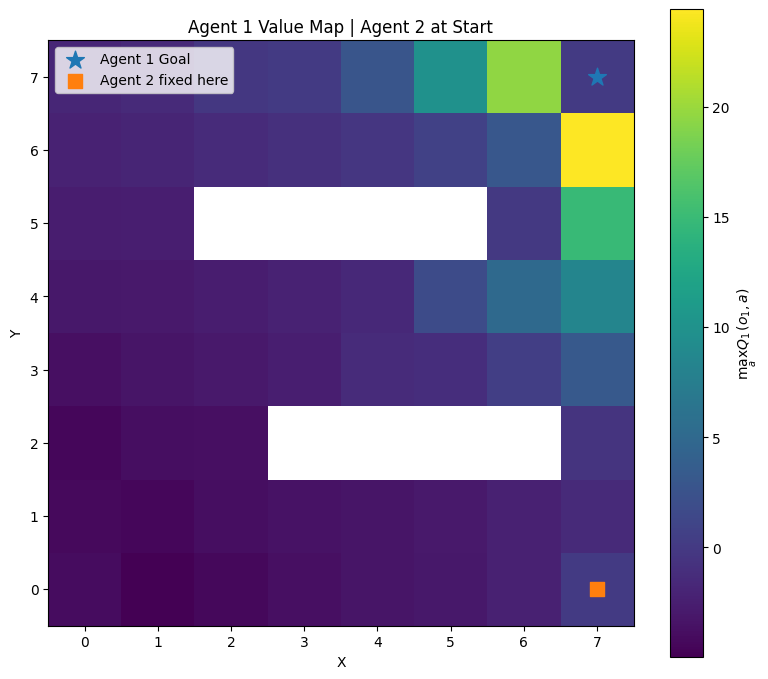

In [29]:
def conditioned_value_map(q_table, other_pos):
    values = np.full((GRID_H, GRID_W), np.nan)

    for y in range(GRID_H):
        for x in range(GRID_W):
            own = (x, y)

            if own in OBSTACLES:
                continue

            state = encode_state(own, other_pos)
            values[y, x] = np.max(q_table[state])

    return values

value_map1 = conditioned_value_map(q1, AGENT2_START)

plt.figure(figsize=(8, 7))
plt.imshow(value_map1, origin="lower")
plt.colorbar(label=r"$\max_a Q_1(o_1,a)$")
plt.scatter(*AGENT1_GOAL, marker="*", s=180, label="Agent 1 Goal")
plt.scatter(*AGENT2_START, marker="s", s=100, label="Agent 2 fixed here")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Agent 1 Value Map | Agent 2 at Start")
plt.legend()
plt.tight_layout()
plt.show()

# 37. Agent 2 Value Map Conditioned on Agent 1's Position

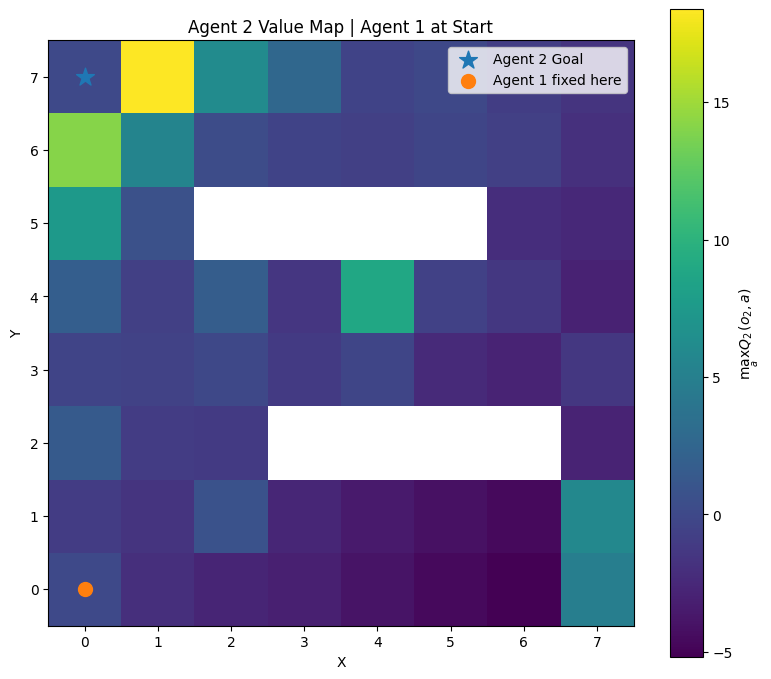

In [30]:
value_map2 = conditioned_value_map(q2, AGENT1_START)

plt.figure(figsize=(8, 7))
plt.imshow(value_map2, origin="lower")
plt.colorbar(label=r"$\max_a Q_2(o_2,a)$")
plt.scatter(*AGENT2_GOAL, marker="*", s=180, label="Agent 2 Goal")
plt.scatter(*AGENT1_START, marker="o", s=100, label="Agent 1 fixed here")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Agent 2 Value Map | Agent 1 at Start")
plt.legend()
plt.tight_layout()
plt.show()

# 38. Conditioned Greedy Policy Maps

Because the other agent's position matters, a policy map must also be conditioned on a fixed location of the other agent.

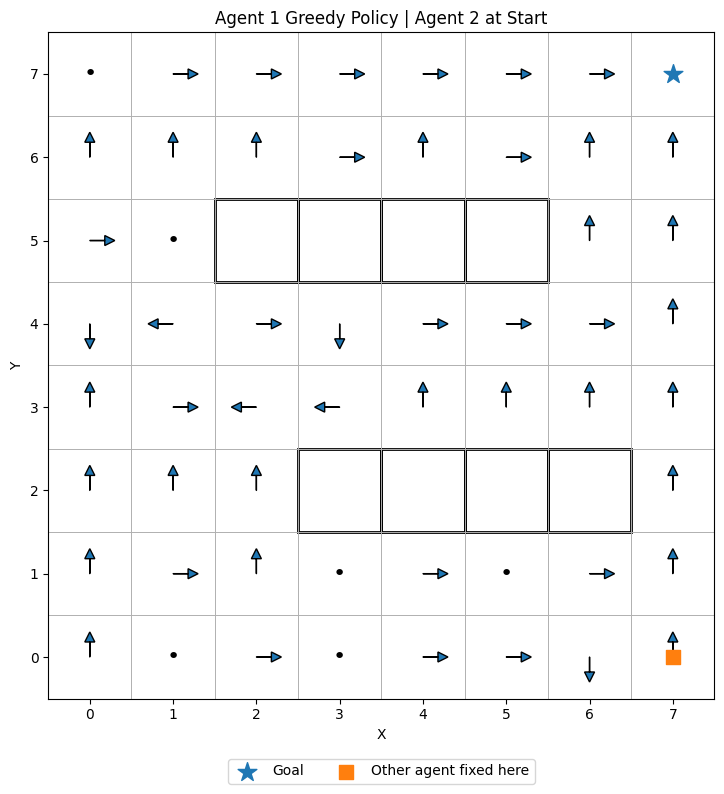

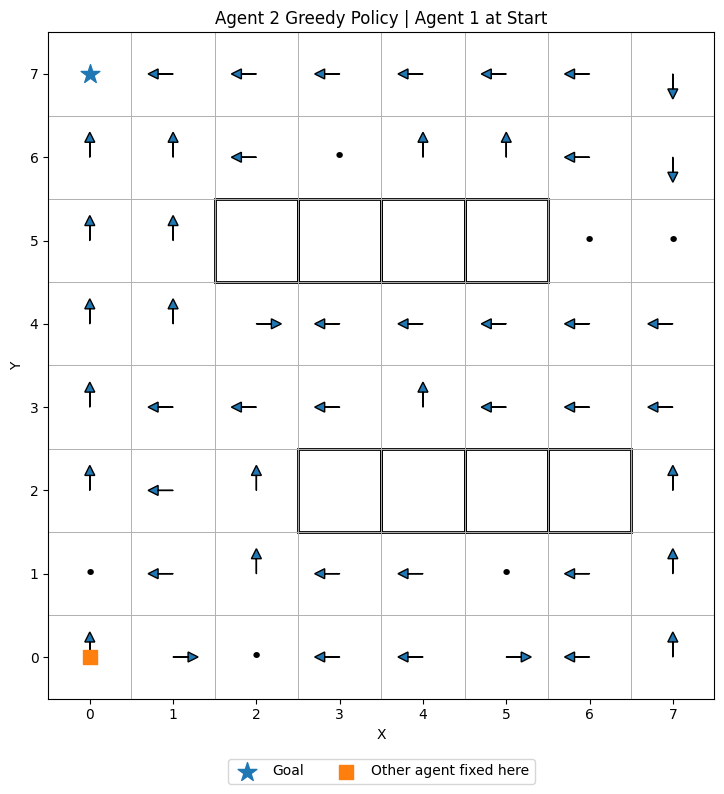

In [31]:
ARROWS = {
    0: (0, 0.30),
    1: (0, -0.30),
    2: (-0.30, 0),
    3: (0.30, 0),
    4: (0, 0)
}

def plot_conditioned_policy(q_table, other_pos, goal, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(-0.5, GRID_H - 0.5)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(-0.5, GRID_W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_H, 1), minor=True)
    ax.grid(which="minor", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    for x, y in OBSTACLES:
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, linewidth=2))

    for y in range(GRID_H):
        for x in range(GRID_W):
            own = (x, y)

            if own in OBSTACLES or own == goal:
                continue

            state = encode_state(own, other_pos)
            action = int(np.argmax(q_table[state]))
            dx, dy = ARROWS[action]

            if action == 4:
                ax.text(x, y, "•", ha="center", va="center", fontsize=16)
            else:
                ax.arrow(
                    x, y, dx, dy,
                    head_width=0.12,
                    head_length=0.12,
                    length_includes_head=True
                )

    ax.scatter(*goal, marker="*", s=200, label="Goal")
    ax.scatter(*other_pos, marker="s", s=110, label="Other agent fixed here")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
    plt.tight_layout()
    plt.show()

plot_conditioned_policy(
    q1, AGENT2_START, AGENT1_GOAL,
    "Agent 1 Greedy Policy | Agent 2 at Start"
)

plot_conditioned_policy(
    q2, AGENT1_START, AGENT2_GOAL,
    "Agent 2 Greedy Policy | Agent 1 at Start"
)

# 39. Animate and Inspect the Learned Two-Agent Policy

Both agents are rendered in the same frames so their interaction can be observed directly.

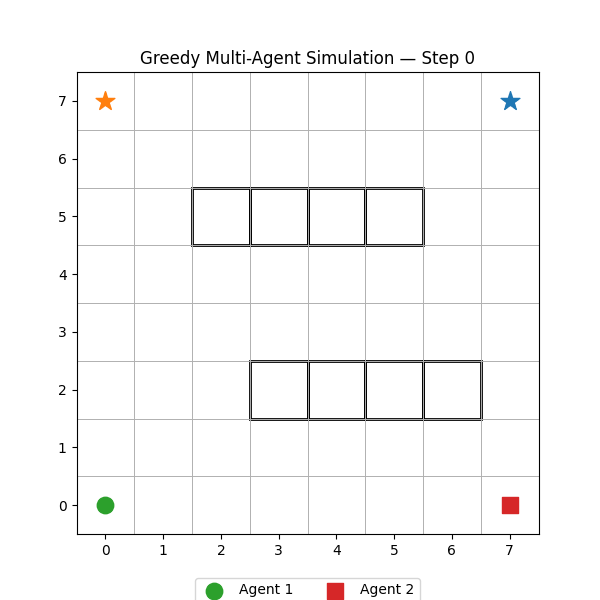

In [32]:
def render_frame(pos1, pos2, step):
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(-0.5, GRID_H - 0.5)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(-0.5, GRID_W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_H, 1), minor=True)
    ax.grid(which="minor", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    for x, y in OBSTACLES:
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, linewidth=2))

    ax.scatter(*AGENT1_GOAL, marker="*", s=200)
    ax.scatter(*AGENT2_GOAL, marker="*", s=200)
    ax.scatter(*pos1, marker="o", s=140, label="Agent 1")
    ax.scatter(*pos2, marker="s", s=140, label="Agent 2")

    ax.set_title(f"Greedy Multi-Agent Simulation — Step {step}")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)

    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()
    plt.close(fig)

    return frame

frames = []

for step, (pos1, pos2) in enumerate(
    zip(evaluation["path1"], evaluation["path2"])
):
    frames.append(render_frame(pos1, pos2, step))

gif_file = "multi_agent_q_learning_simulation.gif"
imageio.mimsave(gif_file, frames, fps=2)

display(Image(filename=gif_file))

## Step-by-Step Greedy Simulation

The GIF provides a continuous view, but for learning it is useful to inspect **every decision separately**.

During this final simulation the Q-tables are **not updated**. Training has already finished.

At every step:

1. each agent constructs its current observation;
2. the corresponding Q-table row is read;
3. the action with the maximum Q-value is selected;
4. both actions are executed simultaneously;
5. the environment checks static obstacles and inter-agent collisions;
6. the next positions and rewards are returned.

For Agent 1,

$$
A_t^1=\arg\max_a Q_1(o_t^1,a),
$$

and for Agent 2,

$$
A_t^2=\arg\max_a Q_2(o_t^2,a).
$$

The following cells show the complete trace, each agent's Q-values at every decision, and one environment figure for **every simulation step**.

In [33]:
def detailed_greedy_simulation(q1, q2, max_steps=150, seed=2026):
    rng = np.random.default_rng(seed)

    pos1 = AGENT1_START
    pos2 = AGENT2_START
    done1 = False
    done2 = False

    path1 = [pos1]
    path2 = [pos2]
    details = []

    cumulative_reward1 = 0.0
    cumulative_reward2 = 0.0
    cumulative_collisions = 0

    for step in range(1, max_steps + 1):
        s1 = encode_state(pos1, pos2)
        s2 = encode_state(pos2, pos1)

        qrow1 = q1[s1].copy()
        qrow2 = q2[s2].copy()

        if done1:
            action1 = 4
        else:
            action1 = greedy_action(q1, s1, rng)

        if done2:
            action2 = 4
        else:
            action2 = greedy_action(q2, s2, rng)

        before1, before2 = pos1, pos2

        (
            next_pos1,
            next_pos2,
            reward1,
            reward2,
            next_done1,
            next_done2,
            info
        ) = multi_agent_step(
            pos1, pos2, action1, action2, done1, done2
        )

        cumulative_reward1 += reward1
        cumulative_reward2 += reward2
        cumulative_collisions += int(info["collision"])

        details.append({
            "Step": step,
            "Agent1 Before": before1,
            "Agent2 Before": before2,
            "Agent1 State ID": s1,
            "Agent2 State ID": s2,
            "Agent1 Q Row": qrow1,
            "Agent2 Q Row": qrow2,
            "Agent1 Action": ACTION_NAMES[action1],
            "Agent2 Action": ACTION_NAMES[action2],
            "Agent1 Selected Q": float(qrow1[action1]),
            "Agent2 Selected Q": float(qrow2[action2]),
            "Agent1 Reward": reward1,
            "Agent2 Reward": reward2,
            "Agent1 After": next_pos1,
            "Agent2 After": next_pos2,
            "Collision": info["collision"],
            "Agent1 Invalid": info["invalid1"],
            "Agent2 Invalid": info["invalid2"],
            "Agent1 Reached Goal": next_done1,
            "Agent2 Reached Goal": next_done2,
            "Agent1 Cumulative Reward": cumulative_reward1,
            "Agent2 Cumulative Reward": cumulative_reward2,
            "Cumulative Collisions": cumulative_collisions
        })

        pos1, pos2 = next_pos1, next_pos2
        done1, done2 = next_done1, next_done2

        path1.append(pos1)
        path2.append(pos2)

        if done1 and done2:
            break

    return details, path1, path2

step_details, step_path1, step_path2 = detailed_greedy_simulation(q1, q2)

step_trace = pd.DataFrame([{
    k: v for k, v in d.items()
    if k not in ("Agent1 Q Row", "Agent2 Q Row")
} for d in step_details])

display(step_trace)

print("Total simulation steps:", len(step_details))
print("Joint goal reached:", step_details[-1]["Agent1 Reached Goal"] and step_details[-1]["Agent2 Reached Goal"])

,Step,Agent1 Before,Agent2 Before,Agent1 State ID,Agent2 State ID,Agent1 Action,Agent2 Action,Agent1 Selected Q,Agent2 Selected Q,Agent1 Reward,...,Agent1 After,Agent2 After,Collision,Agent1 Invalid,Agent2 Invalid,Agent1 Reached Goal,Agent2 Reached Goal,Agent1 Cumulative Reward,Agent2 Cumulative Reward,Cumulative Collisions
0,1,"(0, 0)","(7, 0)",7,448,Up,Up,-3.941,4.876,-1.0,...,"(0, 1)","(7, 1)",False,False,False,False,False,-1.0,-1.0,0
1,2,"(0, 1)","(7, 1)",527,968,Stay,Up,-2.950,6.297,-1.0,...,"(0, 1)","(7, 2)",False,False,False,False,False,-2.0,-2.0,0
2,3,"(0, 1)","(7, 2)",535,1480,Up,Up,-2.065,7.628,-1.0,...,"(0, 2)","(7, 3)",False,False,False,False,False,-3.0,-3.0,0
3,4,"(0, 2)","(7, 3)",1055,2000,Right,Up,-1.042,9.049,-1.0,...,"(1, 2)","(7, 4)",False,False,False,False,False,-4.0,-4.0,0
4,5,"(1, 2)","(7, 4)",1127,2513,Stay,Left,0.011,10.429,-1.0,...,"(1, 2)","(6, 4)",False,False,False,False,False,-5.0,-5.0,0
5,6,"(1, 2)","(6, 4)",1126,2449,Stay,Left,1.205,12.773,-1.0,...,"(1, 2)","(5, 4)",False,False,False,False,False,-6.0,-6.0,0
6,7,"(1, 2)","(5, 4)",1125,2385,Left,Left,2.525,14.664,-1.0,...,"(0, 2)","(4, 4)",False,False,False,False,False,-7.0,-7.0,0
7,8,"(0, 2)","(4, 4)",1060,2320,Right,Left,3.856,16.507,-1.0,...,"(1, 2)","(3, 4)",False,False,False,False,False,-8.0,-8.0,0
8,9,"(1, 2)","(3, 4)",1123,2257,Down,Left,5.047,18.444,-1.0,...,"(1, 1)","(2, 4)",False,False,False,False,False,-9.0,-9.0,0
9,10,"(1, 1)","(2, 4)",610,2185,Right,Left,6.230,20.546,-1.0,...,"(2, 1)","(1, 4)",False,False,False,False,False,-10.0,-10.0,0


Total simulation steps: 22
Joint goal reached: True


### How to read one simulation step

Suppose Agent 1's current Q-table row is

$$
Q_1(o_t^1,:)
=
[q_{\text{Up}},q_{\text{Down}},q_{\text{Left}},q_{\text{Right}},q_{\text{Stay}}].
$$

The greedy action is simply the action corresponding to

$$
\max_a Q_1(o_t^1,a).
$$

Agent 2 performs the same calculation using its own observation and Q-table.

The next cell prints this decision information and draws the environment **step by step**.

### Simulation Step 1
**Before:** Agent 1 (0, 0) | Agent 2 (7, 0)  
**Selected actions:** Agent 1 → `Up`; Agent 2 → `Up`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (0, 1) | Agent 2 (7, 1)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,-3.941,4.876
1,Down,-8.696,-4.397
2,Left,-8.716,-5.797
3,Right,-5.357,-4.431
4,Stay,-4.688,-1.200


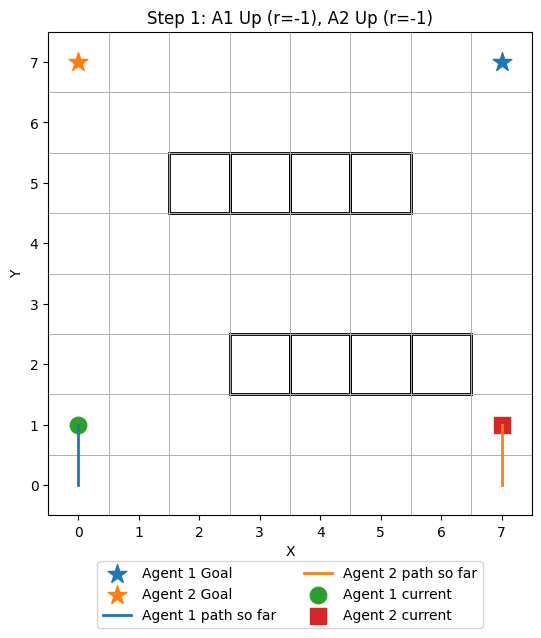

### Simulation Step 2
**Before:** Agent 1 (0, 1) | Agent 2 (7, 1)  
**Selected actions:** Agent 1 → `Stay`; Agent 2 → `Up`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (0, 1) | Agent 2 (7, 2)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,-4.059,6.297
1,Down,-5.282,-2.483
2,Left,-7.533,-2.735
3,Right,-4.367,-1.141
4,Stay,-2.950,1.672


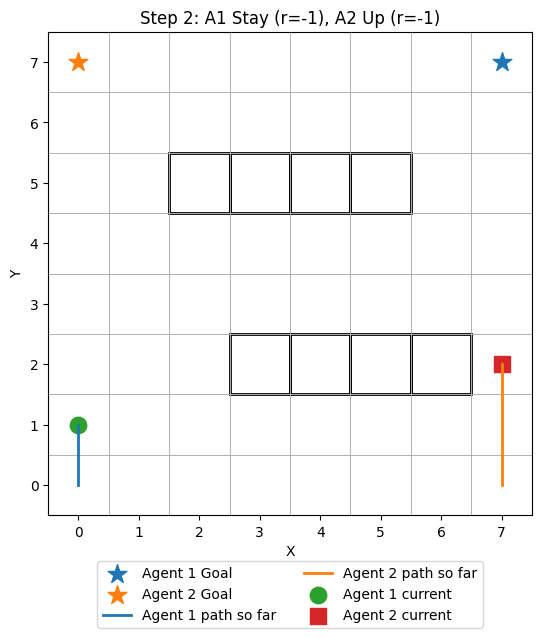

### Simulation Step 3
**Before:** Agent 1 (0, 1) | Agent 2 (7, 2)  
**Selected actions:** Agent 1 → `Up`; Agent 2 → `Up`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (0, 2) | Agent 2 (7, 3)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,-2.065,7.628
1,Down,-4.651,1.069
2,Left,-7.133,-0.103
3,Right,-3.119,-1.511
4,Stay,-3.585,2.452


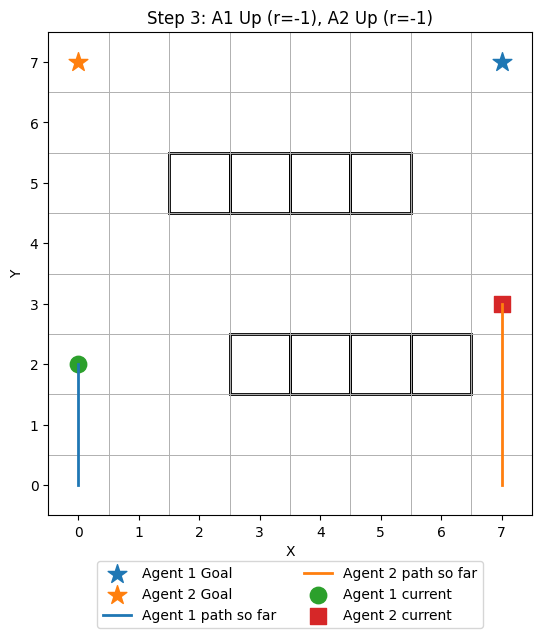

### Simulation Step 4
**Before:** Agent 1 (0, 2) | Agent 2 (7, 3)  
**Selected actions:** Agent 1 → `Right`; Agent 2 → `Up`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (1, 2) | Agent 2 (7, 4)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,-3.717,9.049
1,Down,-3.253,-1.860
2,Left,-6.158,0.996
3,Right,-1.042,0.838
4,Stay,-2.695,3.868


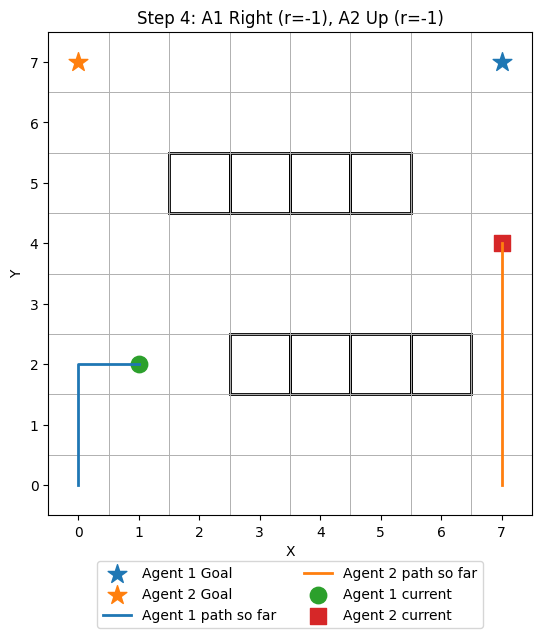

### Simulation Step 5
**Before:** Agent 1 (1, 2) | Agent 2 (7, 4)  
**Selected actions:** Agent 1 → `Stay`; Agent 2 → `Left`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (1, 2) | Agent 2 (6, 4)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,-2.673,-2.046
1,Down,-1.708,3.923
2,Left,-1.756,10.429
3,Right,-3.391,3.243
4,Stay,0.011,5.207


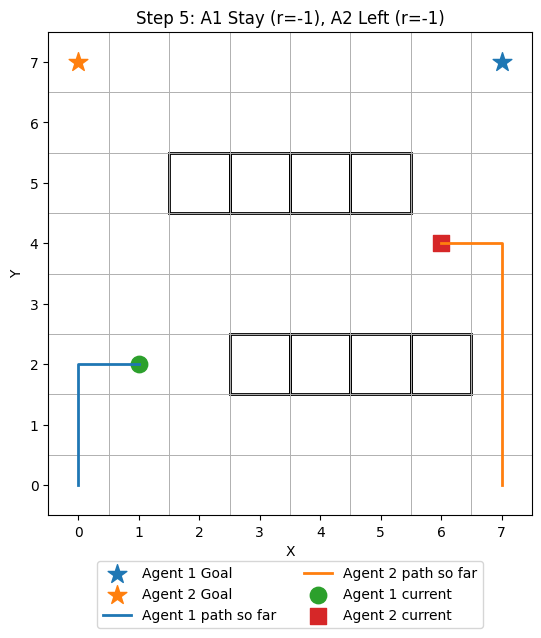

### Simulation Step 6
**Before:** Agent 1 (1, 2) | Agent 2 (6, 4)  
**Selected actions:** Agent 1 → `Stay`; Agent 2 → `Left`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (1, 2) | Agent 2 (5, 4)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,-1.128,0.886
1,Down,-0.618,1.299
2,Left,-1.487,12.773
3,Right,-1.318,5.959
4,Stay,1.205,8.466


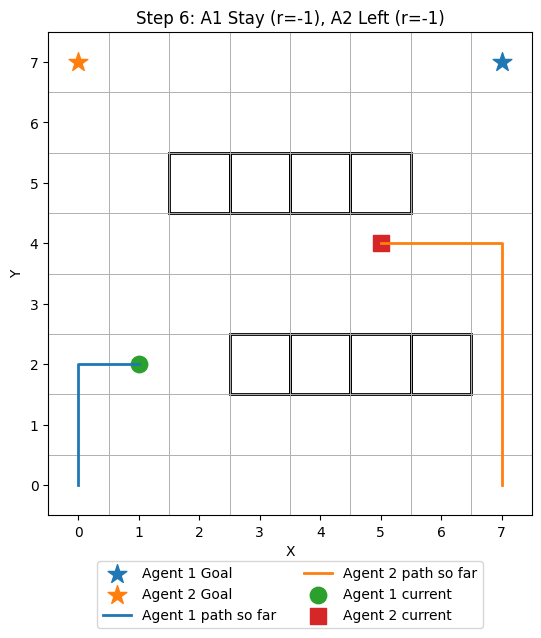

### Simulation Step 7
**Before:** Agent 1 (1, 2) | Agent 2 (5, 4)  
**Selected actions:** Agent 1 → `Left`; Agent 2 → `Left`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (0, 2) | Agent 2 (4, 4)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,1.166,5.053
1,Down,0.824,1.654
2,Left,2.525,14.664
3,Right,-2.313,7.500
4,Stay,0.063,8.006


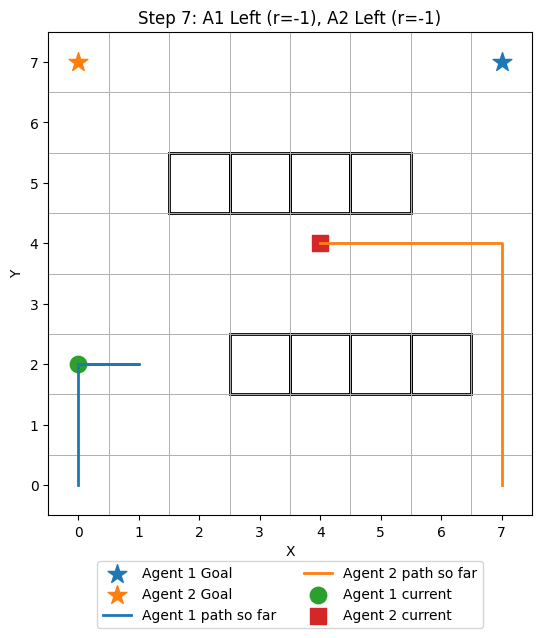

### Simulation Step 8
**Before:** Agent 1 (0, 2) | Agent 2 (4, 4)  
**Selected actions:** Agent 1 → `Right`; Agent 2 → `Left`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (1, 2) | Agent 2 (3, 4)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,-1.480,6.872
1,Down,1.686,7.749
2,Left,-3.015,16.507
3,Right,3.856,8.124
4,Stay,0.603,10.773


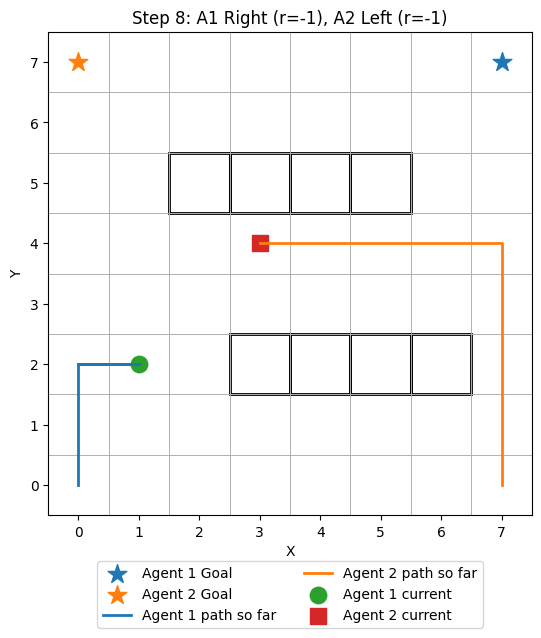

### Simulation Step 9
**Before:** Agent 1 (1, 2) | Agent 2 (3, 4)  
**Selected actions:** Agent 1 → `Down`; Agent 2 → `Left`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (1, 1) | Agent 2 (2, 4)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,1.870,5.915
1,Down,5.047,6.541
2,Left,2.792,18.444
3,Right,2.436,12.239
4,Stay,1.261,11.470


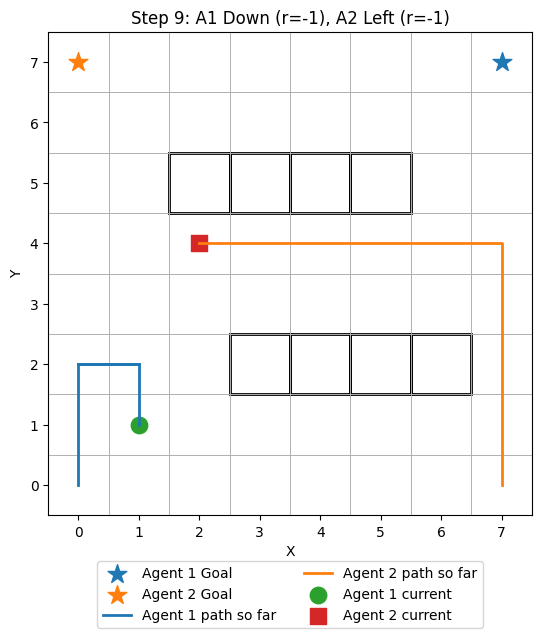

### Simulation Step 10
**Before:** Agent 1 (1, 1) | Agent 2 (2, 4)  
**Selected actions:** Agent 1 → `Right`; Agent 2 → `Left`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (2, 1) | Agent 2 (1, 4)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,2.805,10.872
1,Down,-1.366,10.396
2,Left,4.691,20.546
3,Right,6.230,12.568
4,Stay,4.198,14.785


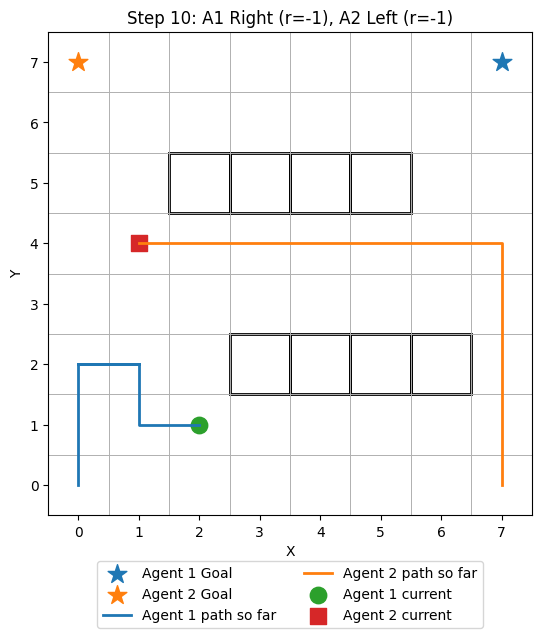

### Simulation Step 11
**Before:** Agent 1 (2, 1) | Agent 2 (1, 4)  
**Selected actions:** Agent 1 → `Stay`; Agent 2 → `Left`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (2, 1) | Agent 2 (0, 4)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,5.657,7.641
1,Down,5.504,15.402
2,Left,6.692,22.806
3,Right,2.086,14.810
4,Stay,7.980,17.467


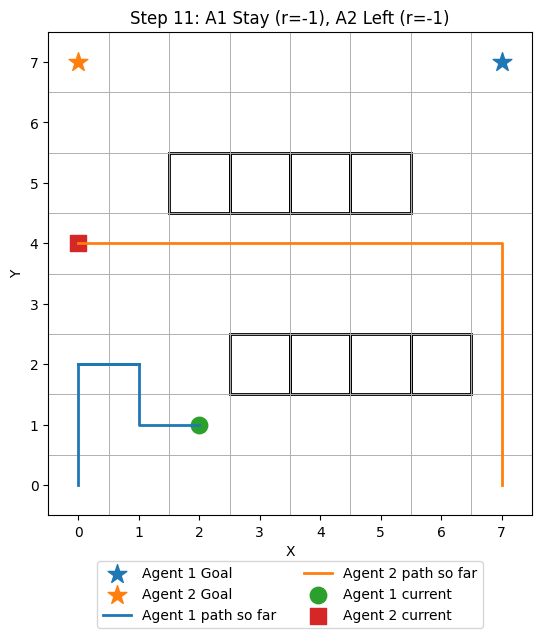

### Simulation Step 12
**Before:** Agent 1 (2, 1) | Agent 2 (0, 4)  
**Selected actions:** Agent 1 → `Up`; Agent 2 → `Up`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (2, 2) | Agent 2 (0, 5)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,9.633,25.120
1,Down,0.411,5.290
2,Left,0.705,6.612
3,Right,3.209,12.153
4,Stay,3.537,13.443


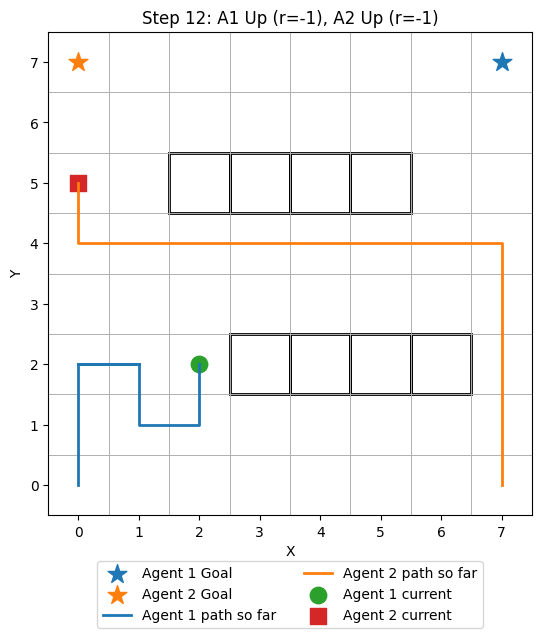

### Simulation Step 13
**Before:** Agent 1 (2, 2) | Agent 2 (0, 5)  
**Selected actions:** Agent 1 → `Up`; Agent 2 → `Up`  
**Rewards:** Agent 1 = -1.0; Agent 2 = -1.0  
**After:** Agent 1 (2, 3) | Agent 2 (0, 6)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,11.183,27.498
1,Down,2.457,8.570
2,Left,2.379,9.909
3,Right,0.854,1.137
4,Stay,3.466,6.446


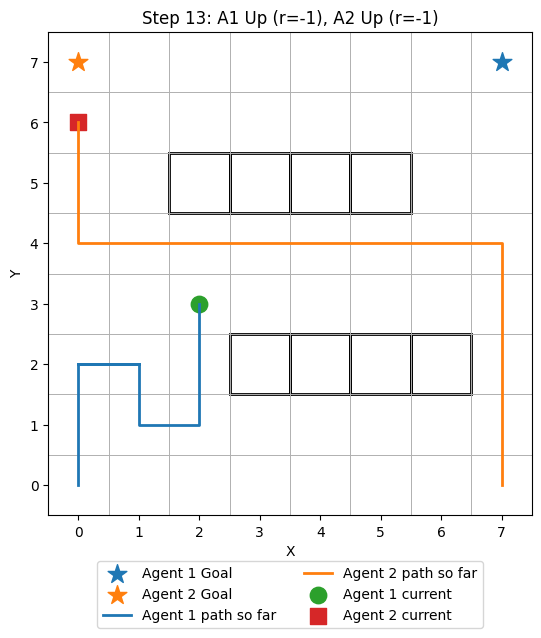

### Simulation Step 14
**Before:** Agent 1 (2, 3) | Agent 2 (0, 6)  
**Selected actions:** Agent 1 → `Right`; Agent 2 → `Up`  
**Rewards:** Agent 1 = -1.0; Agent 2 = 30.0  
**After:** Agent 1 (3, 3) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,6.227,30.000
1,Down,4.901,15.209
2,Left,6.519,12.228
3,Right,12.609,11.472
4,Stay,8.578,19.856


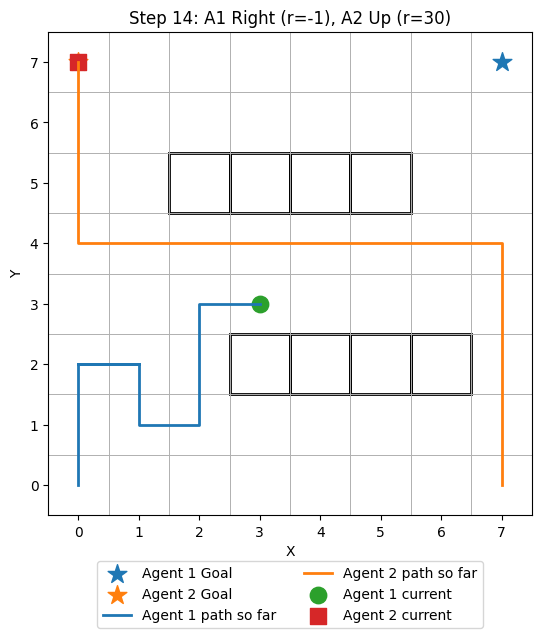

### Simulation Step 15
**Before:** Agent 1 (3, 3) | Agent 2 (0, 7)  
**Selected actions:** Agent 1 → `Up`; Agent 2 → `Stay`  
**Rewards:** Agent 1 = -1.0; Agent 2 = 0.0  
**After:** Agent 1 (3, 4) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,14.917,0.0
1,Down,8.973,0.0
2,Left,10.897,0.0
3,Right,14.497,0.0
4,Stay,12.826,0.0


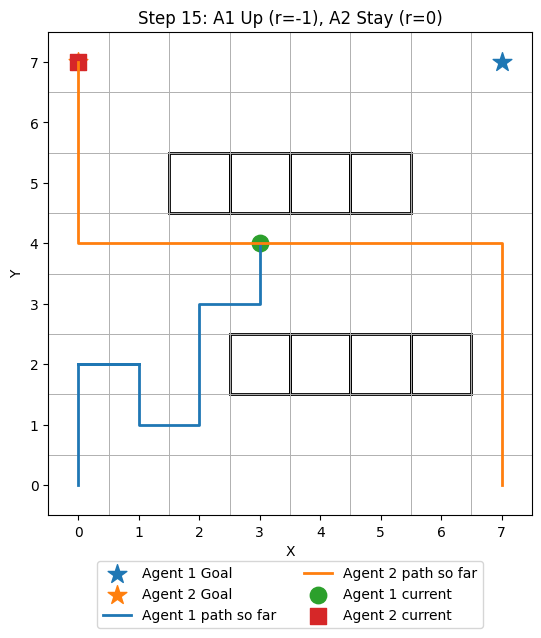

### Simulation Step 16
**Before:** Agent 1 (3, 4) | Agent 2 (0, 7)  
**Selected actions:** Agent 1 → `Right`; Agent 2 → `Stay`  
**Rewards:** Agent 1 = -1.0; Agent 2 = 0.0  
**After:** Agent 1 (4, 4) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,10.843,0.0
1,Down,13.129,0.0
2,Left,13.031,0.0
3,Right,16.755,0.0
4,Stay,14.889,0.0


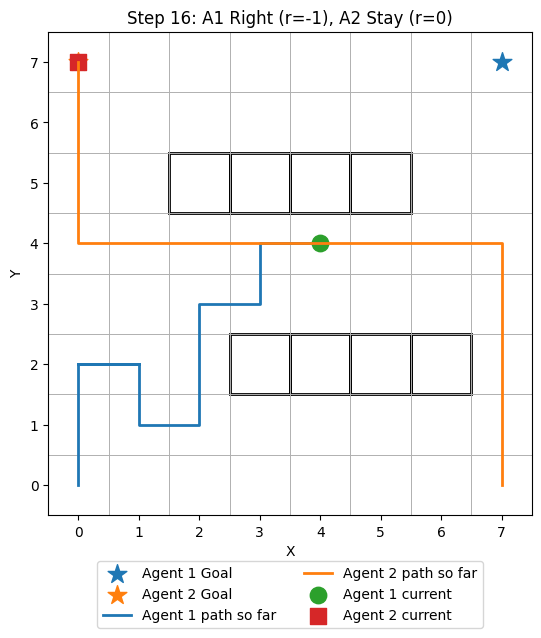

### Simulation Step 17
**Before:** Agent 1 (4, 4) | Agent 2 (0, 7)  
**Selected actions:** Agent 1 → `Right`; Agent 2 → `Stay`  
**Rewards:** Agent 1 = -1.0; Agent 2 = 0.0  
**After:** Agent 1 (5, 4) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,12.720,0.0
1,Down,14.804,0.0
2,Left,14.874,0.0
3,Right,18.689,0.0
4,Stay,16.666,0.0


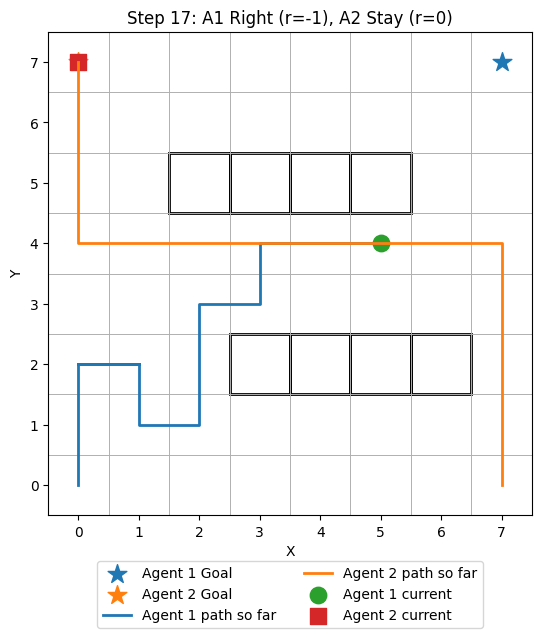

### Simulation Step 18
**Before:** Agent 1 (5, 4) | Agent 2 (0, 7)  
**Selected actions:** Agent 1 → `Right`; Agent 2 → `Stay`  
**Rewards:** Agent 1 = -1.0; Agent 2 = 0.0  
**After:** Agent 1 (6, 4) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,14.650,0.0
1,Down,16.695,0.0
2,Left,16.624,0.0
3,Right,20.725,0.0
4,Stay,18.583,0.0


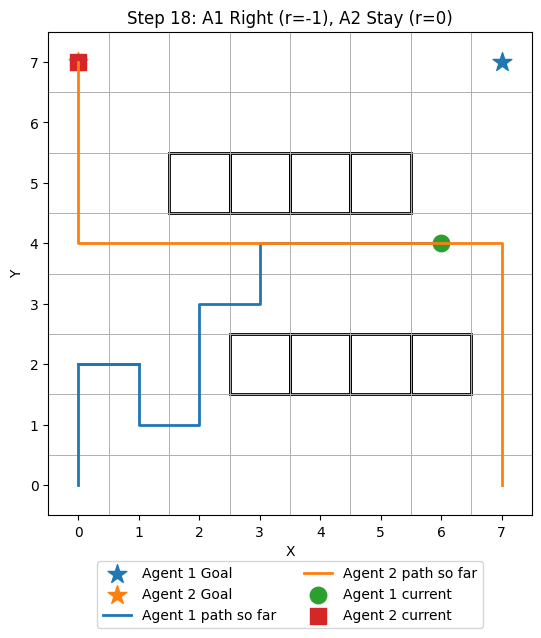

### Simulation Step 19
**Before:** Agent 1 (6, 4) | Agent 2 (0, 7)  
**Selected actions:** Agent 1 → `Right`; Agent 2 → `Stay`  
**Rewards:** Agent 1 = -1.0; Agent 2 = 0.0  
**After:** Agent 1 (7, 4) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,22.814,0.0
1,Down,18.637,0.0
2,Left,18.633,0.0
3,Right,22.869,0.0
4,Stay,20.690,0.0


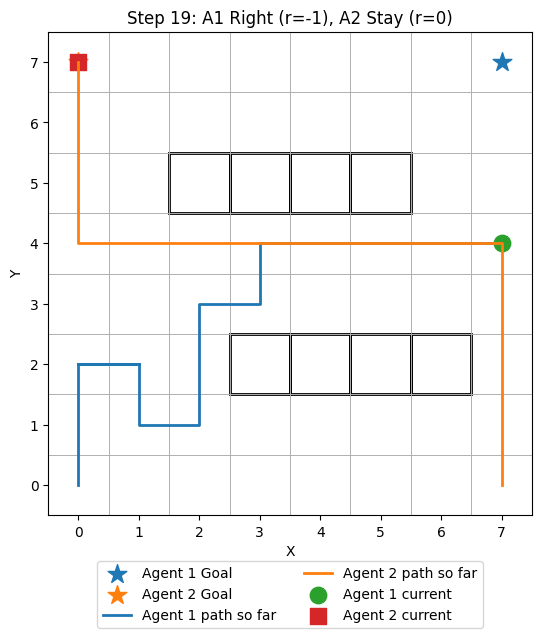

### Simulation Step 20
**Before:** Agent 1 (7, 4) | Agent 2 (0, 7)  
**Selected actions:** Agent 1 → `Up`; Agent 2 → `Stay`  
**Rewards:** Agent 1 = -1.0; Agent 2 = 0.0  
**After:** Agent 1 (7, 5) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,25.125,0.0
1,Down,20.721,0.0
2,Left,20.714,0.0
3,Right,18.867,0.0
4,Stay,22.865,0.0


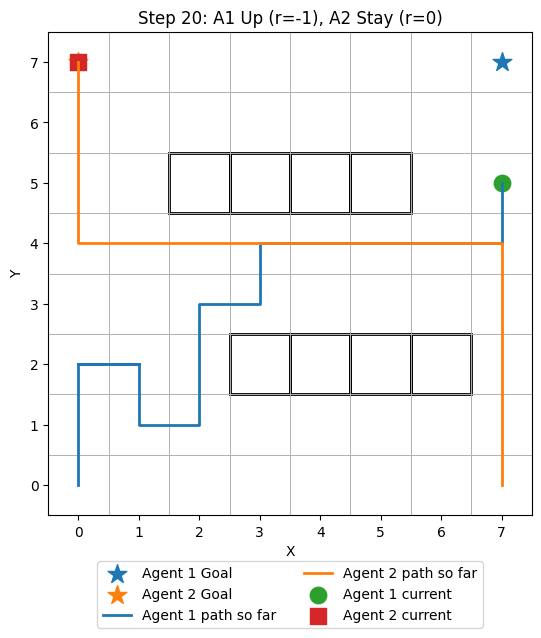

### Simulation Step 21
**Before:** Agent 1 (7, 5) | Agent 2 (0, 7)  
**Selected actions:** Agent 1 → `Up`; Agent 2 → `Stay`  
**Rewards:** Agent 1 = -1.0; Agent 2 = 0.0  
**After:** Agent 1 (7, 6) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,27.500,0.0
1,Down,22.857,0.0
2,Left,22.867,0.0
3,Right,21.121,0.0
4,Stay,25.123,0.0


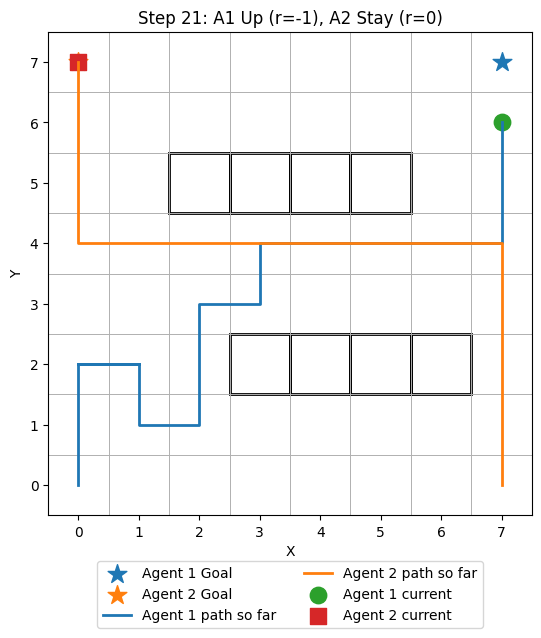

### Simulation Step 22
**Before:** Agent 1 (7, 6) | Agent 2 (0, 7)  
**Selected actions:** Agent 1 → `Up`; Agent 2 → `Stay`  
**Rewards:** Agent 1 = 30.0; Agent 2 = 0.0  
**After:** Agent 1 (7, 7) | Agent 2 (0, 7)  
**Collision:** False | **A1 invalid:** False | **A2 invalid:** False

,Action,Agent 1 Q,Agent 2 Q
0,Up,30.000,0.0
1,Down,25.124,0.0
2,Left,25.123,0.0
3,Right,23.500,0.0
4,Stay,27.498,0.0


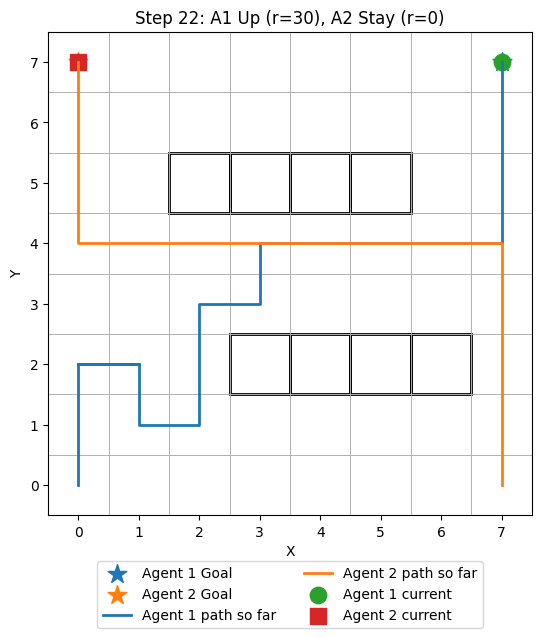

In [34]:
from IPython.display import display, Markdown

def show_simulation_step(detail, path1, path2):
    step = detail["Step"]

    q_decision = pd.DataFrame({
        "Action": ACTION_NAMES,
        "Agent 1 Q": detail["Agent1 Q Row"],
        "Agent 2 Q": detail["Agent2 Q Row"]
    })

    display(Markdown(
        f"### Simulation Step {step}\n"
        f"**Before:** Agent 1 {detail['Agent1 Before']} | Agent 2 {detail['Agent2 Before']}  \n"
        f"**Selected actions:** Agent 1 → `{detail['Agent1 Action']}`; "
        f"Agent 2 → `{detail['Agent2 Action']}`  \n"
        f"**Rewards:** Agent 1 = {detail['Agent1 Reward']:.1f}; "
        f"Agent 2 = {detail['Agent2 Reward']:.1f}  \n"
        f"**After:** Agent 1 {detail['Agent1 After']} | Agent 2 {detail['Agent2 After']}  \n"
        f"**Collision:** {detail['Collision']} | "
        f"**A1 invalid:** {detail['Agent1 Invalid']} | "
        f"**A2 invalid:** {detail['Agent2 Invalid']}"
    ))

    display(q_decision)

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(-0.5, GRID_H - 0.5)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(-0.5, GRID_W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_H, 1), minor=True)
    ax.grid(which="minor", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    for x, y in OBSTACLES:
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, linewidth=2))

    ax.scatter(*AGENT1_GOAL, marker="*", s=200, label="Agent 1 Goal")
    ax.scatter(*AGENT2_GOAL, marker="*", s=200, label="Agent 2 Goal")

    p1 = path1[:step + 1]
    p2 = path2[:step + 1]

    ax.plot([p[0] for p in p1], [p[1] for p in p1], linewidth=2, label="Agent 1 path so far")
    ax.plot([p[0] for p in p2], [p[1] for p in p2], linewidth=2, label="Agent 2 path so far")

    ax.scatter(*detail["Agent1 After"], marker="o", s=140, label="Agent 1 current")
    ax.scatter(*detail["Agent2 After"], marker="s", s=140, label="Agent 2 current")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(
        f"Step {step}: "
        f"A1 {detail['Agent1 Action']} (r={detail['Agent1 Reward']:.0f}), "
        f"A2 {detail['Agent2 Action']} (r={detail['Agent2 Reward']:.0f})"
    )
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
    plt.tight_layout()

    display(fig)
    plt.close(fig)

for detail in step_details:
    show_simulation_step(detail, step_path1, step_path2)

## Simulation Reward Accumulation by Step

The training graphs use episode-level reward. The final simulation can also be examined at the **within-episode** level.

For Agent $i$, cumulative reward after step $k$ is

$$
G_i(k)
=
\sum_{t=1}^{k}r_t^i.
$$

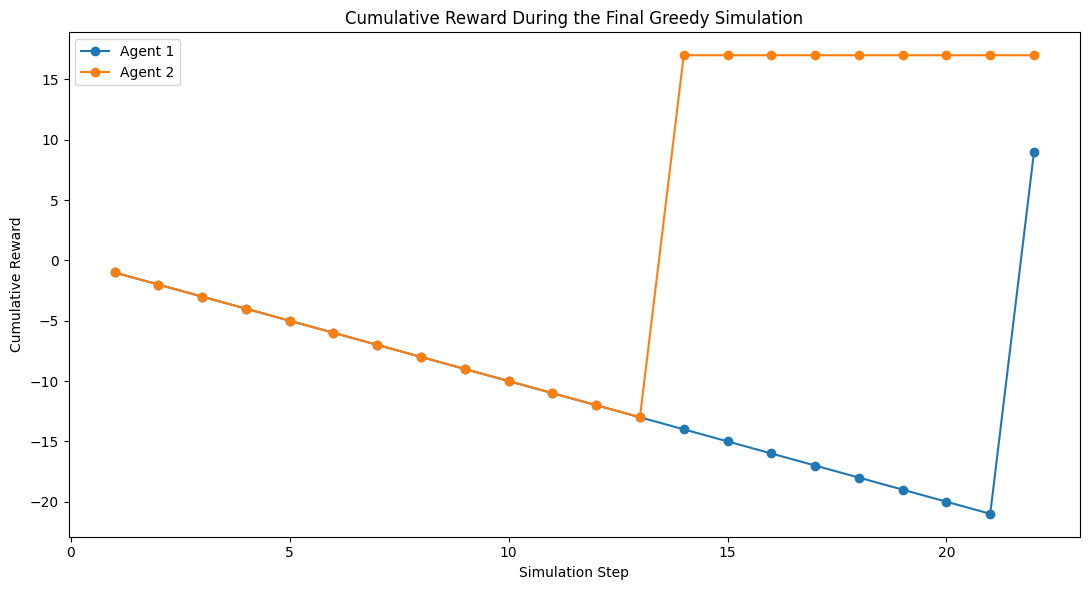

In [35]:
simulation_steps = [d["Step"] for d in step_details]
cum_reward1 = [d["Agent1 Cumulative Reward"] for d in step_details]
cum_reward2 = [d["Agent2 Cumulative Reward"] for d in step_details]

plt.figure(figsize=(11, 6))
plt.plot(simulation_steps, cum_reward1, marker="o", label="Agent 1")
plt.plot(simulation_steps, cum_reward2, marker="o", label="Agent 2")
plt.xlabel("Simulation Step")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward During the Final Greedy Simulation")
plt.legend()
plt.tight_layout()
plt.show()

## Distance to Goal at Every Simulation Step

The Manhattan distance is

$$
d_i(t)
=
|x_i(t)-x_i^{\text{goal}}|
+
|y_i(t)-y_i^{\text{goal}}|.
$$

This graph helps show whether each agent is generally moving toward its goal while coordinating with the other agent.

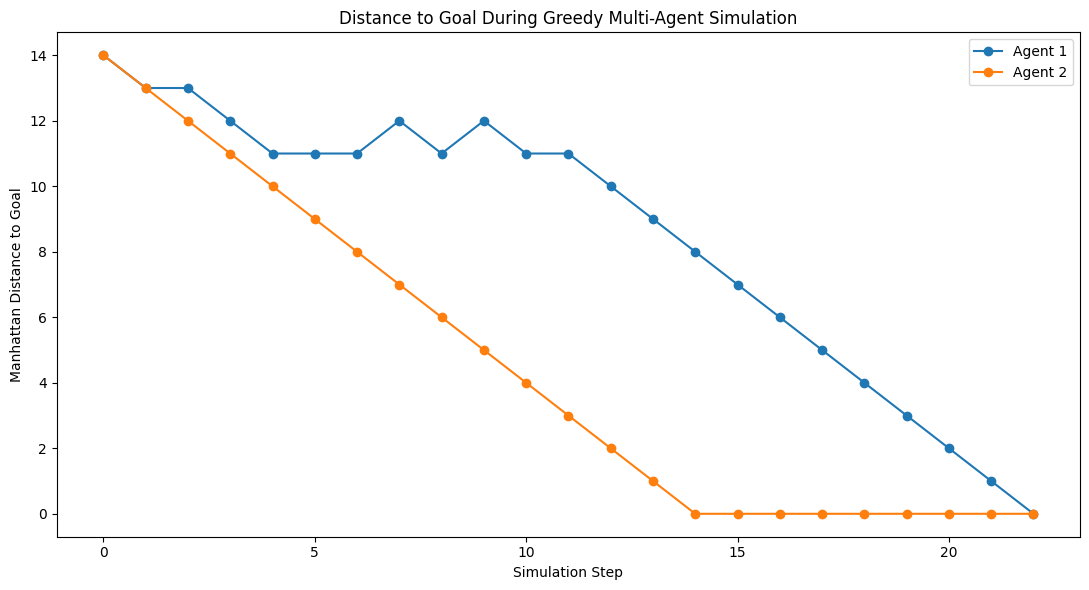

In [36]:
def manhattan(p, goal):
    return abs(p[0] - goal[0]) + abs(p[1] - goal[1])

positions1 = [AGENT1_START] + [d["Agent1 After"] for d in step_details]
positions2 = [AGENT2_START] + [d["Agent2 After"] for d in step_details]

distance1 = [manhattan(p, AGENT1_GOAL) for p in positions1]
distance2 = [manhattan(p, AGENT2_GOAL) for p in positions2]

plt.figure(figsize=(11, 6))
plt.plot(range(len(distance1)), distance1, marker="o", label="Agent 1")
plt.plot(range(len(distance2)), distance2, marker="o", label="Agent 2")
plt.xlabel("Simulation Step")
plt.ylabel("Manhattan Distance to Goal")
plt.title("Distance to Goal During Greedy Multi-Agent Simulation")
plt.legend()
plt.tight_layout()
plt.show()

## Action Sequence During the Final Simulation

This table makes the coordination sequence easy to inspect without relying only on animation.

In [37]:
action_sequence = step_trace[
    [
        "Step",
        "Agent1 Before",
        "Agent1 Action",
        "Agent1 Reward",
        "Agent1 After",
        "Agent2 Before",
        "Agent2 Action",
        "Agent2 Reward",
        "Agent2 After",
        "Collision"
    ]
].copy()

display(action_sequence)

,Step,Agent1 Before,Agent1 Action,Agent1 Reward,Agent1 After,Agent2 Before,Agent2 Action,Agent2 Reward,Agent2 After,Collision
0,1,"(0, 0)",Up,-1.0,"(0, 1)","(7, 0)",Up,-1.0,"(7, 1)",False
1,2,"(0, 1)",Stay,-1.0,"(0, 1)","(7, 1)",Up,-1.0,"(7, 2)",False
2,3,"(0, 1)",Up,-1.0,"(0, 2)","(7, 2)",Up,-1.0,"(7, 3)",False
3,4,"(0, 2)",Right,-1.0,"(1, 2)","(7, 3)",Up,-1.0,"(7, 4)",False
4,5,"(1, 2)",Stay,-1.0,"(1, 2)","(7, 4)",Left,-1.0,"(6, 4)",False
5,6,"(1, 2)",Stay,-1.0,"(1, 2)","(6, 4)",Left,-1.0,"(5, 4)",False
6,7,"(1, 2)",Left,-1.0,"(0, 2)","(5, 4)",Left,-1.0,"(4, 4)",False
7,8,"(0, 2)",Right,-1.0,"(1, 2)","(4, 4)",Left,-1.0,"(3, 4)",False
8,9,"(1, 2)",Down,-1.0,"(1, 1)","(3, 4)",Left,-1.0,"(2, 4)",False
9,10,"(1, 1)",Right,-1.0,"(2, 1)","(2, 4)",Left,-1.0,"(1, 4)",False


## Learned Policy vs. Random-Action Baseline

A trained policy is easier to interpret when compared with agents that act randomly.

The next evaluation compares:

- the learned greedy two-agent policy;
- two random-action agents.

We compare:

- joint success rate;
- mean episode length;
- mean Agent 1 reward;
- mean Agent 2 reward;
- mean inter-agent collisions.

In [38]:
def evaluate_many(q1, q2, episodes=300, mode="greedy", max_steps=150, seed=10000):
    rng = np.random.default_rng(seed)

    joint_successes = []
    steps_list = []
    rewards1 = []
    rewards2 = []
    collision_list = []

    for ep in range(episodes):
        pos1 = AGENT1_START
        pos2 = AGENT2_START
        done1 = False
        done2 = False
        total_r1 = 0.0
        total_r2 = 0.0
        collisions = 0

        for step in range(1, max_steps + 1):
            s1 = encode_state(pos1, pos2)
            s2 = encode_state(pos2, pos1)

            if done1:
                a1 = 4
            elif mode == "greedy":
                a1 = greedy_action(q1, s1, rng)
            else:
                a1 = int(rng.integers(N_ACTIONS))

            if done2:
                a2 = 4
            elif mode == "greedy":
                a2 = greedy_action(q2, s2, rng)
            else:
                a2 = int(rng.integers(N_ACTIONS))

            (
                pos1, pos2,
                r1, r2,
                done1, done2,
                info
            ) = multi_agent_step(pos1, pos2, a1, a2, done1, done2)

            total_r1 += r1
            total_r2 += r2
            collisions += int(info["collision"])

            if done1 and done2:
                break

        joint_successes.append(int(done1 and done2))
        steps_list.append(step)
        rewards1.append(total_r1)
        rewards2.append(total_r2)
        collision_list.append(collisions)

    return {
        "Joint Success Rate": np.mean(joint_successes),
        "Mean Steps": np.mean(steps_list),
        "Mean Agent 1 Reward": np.mean(rewards1),
        "Mean Agent 2 Reward": np.mean(rewards2),
        "Mean Collisions": np.mean(collision_list)
    }

greedy_metrics = evaluate_many(q1, q2, mode="greedy")
random_metrics = evaluate_many(q1, q2, mode="random")

baseline_comparison = pd.DataFrame([
    {"Policy": "Random", **random_metrics},
    {"Policy": "Learned Greedy", **greedy_metrics}
]).set_index("Policy")

display(baseline_comparison)

,Joint Success Rate,Mean Steps,Mean Agent 1 Reward,Mean Agent 2 Reward,Mean Collisions
Policy,,,,,
Random,0.017,149.29,-270.263,-269.72,2.2
Learned Greedy,1.000,22.00,9.000,17.00,0.0


### Joint Success Rate: Random vs. Learned Policy

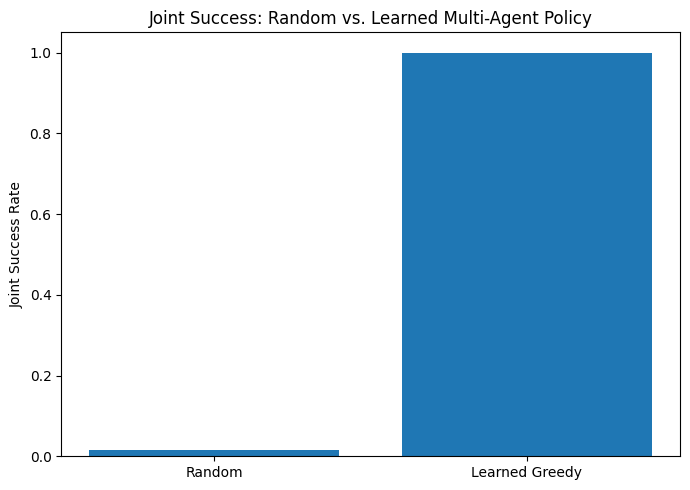

In [39]:
plt.figure(figsize=(7, 5))
plt.bar(
    ["Random", "Learned Greedy"],
    [
        baseline_comparison.loc["Random", "Joint Success Rate"],
        baseline_comparison.loc["Learned Greedy", "Joint Success Rate"]
    ]
)
plt.ylabel("Joint Success Rate")
plt.ylim(0, 1.05)
plt.title("Joint Success: Random vs. Learned Multi-Agent Policy")
plt.tight_layout()
plt.show()

### Mean Episode Steps: Random vs. Learned Policy

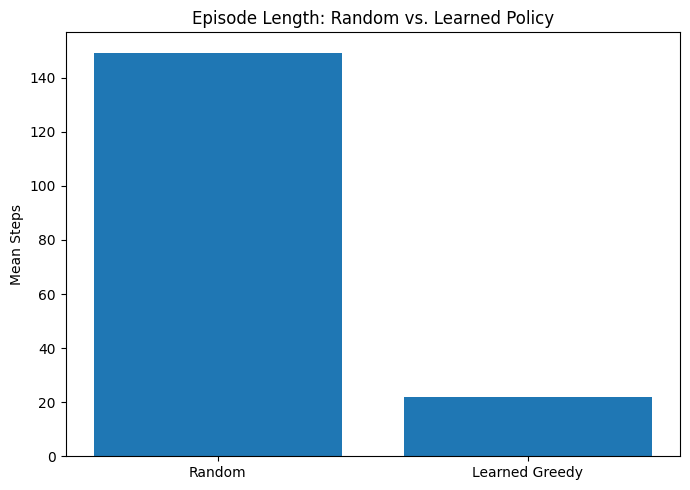

In [40]:
plt.figure(figsize=(7, 5))
plt.bar(
    ["Random", "Learned Greedy"],
    [
        baseline_comparison.loc["Random", "Mean Steps"],
        baseline_comparison.loc["Learned Greedy", "Mean Steps"]
    ]
)
plt.ylabel("Mean Steps")
plt.title("Episode Length: Random vs. Learned Policy")
plt.tight_layout()
plt.show()

### Mean Inter-Agent Collisions: Random vs. Learned Policy

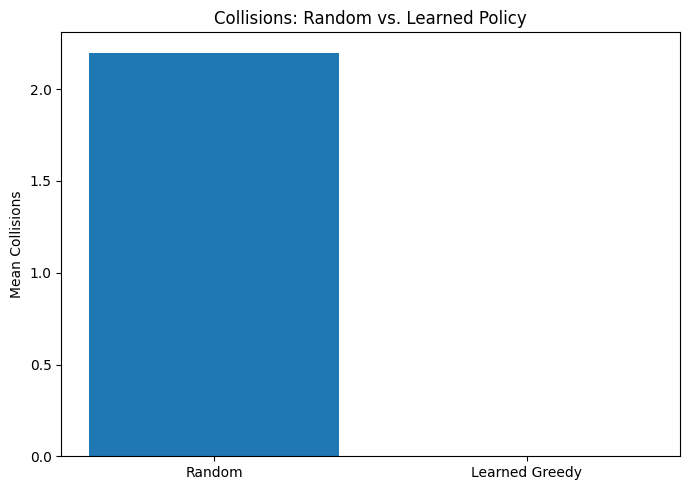

In [41]:
plt.figure(figsize=(7, 5))
plt.bar(
    ["Random", "Learned Greedy"],
    [
        baseline_comparison.loc["Random", "Mean Collisions"],
        baseline_comparison.loc["Learned Greedy", "Mean Collisions"]
    ]
)
plt.ylabel("Mean Collisions")
plt.title("Collisions: Random vs. Learned Policy")
plt.tight_layout()
plt.show()

## Final Multi-Agent Results Summary

At this point the notebook has examined multi-agent learning from four levels:

### Mathematical level

- Markov-game state and joint actions;
- separate observations;
- separate rewards;
- individual Q-learning equations;
- TD targets and TD errors.

### Training level

- first 60 Q-updates per agent;
- numerical update calculations;
- individual Q-tables;
- Q-table evolution;
- reward curves;
- success curves;
- collision and invalid-move curves;
- individual and combined Q-table convergence.

### Policy level

- conditioned value maps;
- conditioned greedy policy maps;
- learned paths;
- greedy evaluation.

### Simulation level

- animation;
- complete step-by-step state/action/reward trace;
- Q-values used at every decision;
- one grid visualization for every step;
- cumulative simulation rewards;
- distance-to-goal trajectories;
- comparison with a random-action baseline.

# 40. Why the State Space Grows Quickly

For one agent in an $8\times8$ grid:

$$
64
$$

position states.

For two agents:

$$
64^2=4096
$$

joint-position states.

For three agents:

$$
64^3=262{,}144.
$$

In general, if each of $N$ agents can occupy $M$ positions, a full joint-position representation can grow as

$$
M^N.
$$

This exponential growth is one form of the **curse of dimensionality**.

# 41. Independent vs. Joint-Action Q-Learning

This notebook uses independent action values:

$$
Q_i(o_i,a_i).
$$

A centralized alternative could learn

$$
Q(S,a_1,a_2).
$$

Because each agent has five actions, the two-agent joint action space contains

$$
5^2=25
$$

joint actions.

For $N$ agents with $m$ actions each,

$$
|\mathcal A_{\text{joint}}|
=
m^N.
$$

Joint-action learning can represent coordination more directly, but its table grows rapidly.

# 42. Cooperative, Competitive, and Mixed Multi-Agent RL

### Cooperative

Agents have aligned goals.

Example: warehouse robots completing different deliveries without blocking one another.

### Competitive

One agent's improvement may reduce another agent's outcome.

Example: adversarial game players.

### Mixed

Agents cooperate in some situations and compete in others.

The environment in this notebook is mainly **cooperative** because the desired episode outcome is for both agents to reach their goals safely.

# 43. Centralized Training and Decentralized Execution

A common MARL framework is

$$
\boxed{
\text{Centralized Training}
\rightarrow
\text{Decentralized Execution}
}
$$

During training, an algorithm may use global information about all agents.

During deployment, each agent may act from only its own local observation.

This notebook is simpler: each agent directly observes both positions and independently learns its own Q-table.

# 44. Partial Observability

A physical robot may not know the exact position of every other robot.

Instead, it may receive a local observation:

$$
o_i=
(
\text{own position},
\text{nearby obstacle readings},
\text{nearby robot detections}
).
$$

Then the complete global state is not directly available to every agent.

This creates a partially observable multi-agent problem and makes learning more difficult.

# 45. Connection to Deep Multi-Agent Reinforcement Learning

Tabular Q-learning stores an explicit value for every state-action pair.

When the state includes:

- many robots;
- continuous locations;
- velocities;
- sensor readings;
- images;
- large maps;

the table becomes impractical.

Instead, a neural network can approximate

$$
Q_i(o_i,a_i;\theta_i).
$$

This leads toward deep MARL methods such as:

- multi-agent DQN variants;
- value decomposition methods;
- actor-critic MARL;
- multi-agent PPO.

# 46. Final Summary

The global state is

$$
S_t=(p_t^1,p_t^2),
$$

while each learner uses its own ordered observation:

$$
o_t^1=(p_t^1,p_t^2),
$$

$$
o_t^2=(p_t^2,p_t^1).
$$

The agents learn separate Q-functions:

$$
Q_1(o_1,a_1),
\qquad
Q_2(o_2,a_2).
$$

Both agents:

- learn simultaneously;
- use $\epsilon$-greedy exploration;
- avoid static obstacles;
- learn to reduce invalid actions;
- learn to avoid one another;
- attempt to reach separate goals.

The main lesson is:

$$
\boxed{
\text{Multi-agent Q-learning}
\neq
\text{simply running single-agent Q-learning twice}
}
$$

The other learning agent changes the transition dynamics, enlarges the state space, creates coordination requirements, and introduces non-stationarity.